## Figures S5–S8 — Classical waves in finite periodic boxes

This notebook reproduces **Figures S5, S6, S7, and S8** of the supplementary material.

It studies waves in a **positive-$F(x)$** (positive harmonic permittivity)
1D periodic medium. The early cells compute the Floquet map and Bloch waves as
preliminary steps (those figures appear in Figs S2–S3); the box-mode results
start at the finite-slab solver section below.


In [44]:
import numpy as np
import scipy.special as sp
from scipy.sparse import diags
from scipy.optimize import fsolve
from scipy.sparse.linalg import eigs
from scipy.linalg import eigh
from scipy.special import mathieu_a, mathieu_cem, mathieu_b, mathieu_sem
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from numpy import linalg as LA
import scipy.linalg
import cmath as cm
import matplotlib.pyplot as plt

In [45]:
def equation_lin(t, y, toto, titi):  
    qq, pp  = y
    #dydt = [pp, -(toto-2*titi*np.cos(2*t))*qq]
    dydt = [pp, -(toto+2*titi*np.cos(2*t))*qq]
    return dydt


In [46]:
def find(element, vector):
    
    """ Function returning index of an element in a vector """
    
    for i in range(len(vector)):
        if vector[i] == element:
            return (i)

In [47]:
def sol_comp_mode_floquet(t, y, a, q, sn):
    JJ = np.array([ [0.,1 ],
                       [-a+2*q*np.cos(2*t),0.] ],dtype=complex)
    Is = np.array([ [sn,0.],
                       [0.,sn] ],dtype=complex)
    mat_B   = JJ - Is 
    dydt    = np.dot(mat_B,y)
    return dydt



In [48]:
from scipy.signal import find_peaks

def find_fft_peaks(fft_wave_shifted, k, height=None, distance=None):
    """
    Find the peaks of the FFT and their corresponding wavenumbers.
    
    Parameters:
    - fft_wave_shifted (np.ndarray): The shifted FFT amplitude array.
    - k (np.ndarray): The wavenumbers corresponding to the FFT.
    - height (float, optional): Minimum amplitude for a peak. Default is None.
    - distance (int, optional): Minimum distance between peaks in indices. Default is None.
    
    Returns:
    - peak_k (np.ndarray): Wavenumbers corresponding to the peaks.
    - peak_amplitudes (np.ndarray): Amplitudes of the peaks.
    """
    # Find peaks in the FFT amplitude
    peaks, _ = find_peaks(np.abs(fft_wave_shifted), height=height, distance=distance)
    
    # Extract wavenumbers and amplitudes at the peaks
    peak_k = k[peaks]
    peak_amplitudes = np.abs(fft_wave_shifted[peaks])
    
    # Return unique peaks sorted by wavenumber
    unique_indices = np.argsort(peak_k)
    return peak_k[unique_indices], peak_amplitudes[unique_indices]

In [49]:
def compute_hill_eigenvalues1(delta, eps, TT):
    """
    Computes the sorted eigenvalues of the Hill matrix for the given parameters.

    Parameters:
        delta (float): Parameter delta.
        beta (float): Parameter beta.
        Q (float): Parameter Q.
        eps (float): Parameter epsilon.
        TT (float): Period.
        Hmax (int): Truncation order of the Hill matrix (default is 5).

    Returns:
        np.ndarray: Sorted eigenvalues of the Hill matrix.
    """
    nstate = 2  # Dimension of the state space
    Hmax = 10
    # Initialize the Hill matrix
    HILL = np.zeros((nstate * (2 * Hmax + 1), nstate * (2 * Hmax + 1)), dtype=complex)
    
    # Identity matrix
    II = np.eye(nstate)
    
    # Constant term of the Jacobian
    J0 = np.array([[0, 1], [-delta, 0.]])
    
    # Term in exp(2i/tau) and exp(-2i/tau)
    Jun = np.array([[0, 0], [-eps, 0]])
    
    # Populate the Hill matrix
    for t in range(1, Hmax * 2 + 2):
        idx = (t - 1) * nstate
        HILL[idx:idx + nstate, idx:idx + nstate] = J0 + (Hmax - (t - 1)) * (2 * np.pi / TT) * 1j * II
        if t > 1:
            prev_idx = (t - 2) * nstate
            HILL[prev_idx:prev_idx + nstate, idx:idx + nstate] = Jun
            HILL[idx:idx + nstate, prev_idx:prev_idx + nstate] = Jun
    
    # Compute eigenvalues and eigenvectors
    eigtot, V = np.linalg.eig(HILL)
    eigtot = eigtot[np.argsort(np.imag(eigtot))]  # Sort eigenvalues by imaginary part

    # Weighted arithmetic mean (center of mass) calculation
    XX = np.repeat(np.arange(-Hmax, Hmax + 1), nstate)
    abs_V = np.abs(V)
    Wmean = np.sum(XX[:, None] * abs_V, axis=0) / np.sum(abs_V, axis=0)

    # Sort by weighted arithmetic mean
    sorted_indices = np.argsort(Wmean)
    Wmean_sorted = Wmean[sorted_indices]

    # Filter based on balanced eigenvectors
    ind2 = np.where((np.round(Wmean_sorted, 6) <= 0.5) & (np.round(Wmean_sorted, 6) > -0.5))[0]

    # Select the most converged eigenvalues and eigenvectors
    if len(ind2) == nstate:
        # Further sort by the absolute imaginary part of eigenvalues
        ind3 = np.argsort(np.abs(np.imag(eigtot[sorted_indices[ind2]])))
        Fexponents = eigtot[sorted_indices[ind2[ind3]]]
        VecHill = V[:, sorted_indices[ind2[ind3]]]
    else:
        # If not enough converged eigenvalues, return NaN arrays
        Fexponents = np.full((nstate,), np.nan + 1j * np.nan)
        VecHill = np.full((nstate * (2 * Hmax + 1), nstate), np.nan + 1j * np.nan)

    return Fexponents, VecHill


In [50]:
def compute_hill_eigenvalues2(delta, eps, TT):
    """
    Computes the sorted eigenvalues of the Hill matrix for the given parameters.

    Parameters:
        delta (float): Parameter delta.
        beta (float): Parameter beta.
        Q (float): Parameter Q.
        eps (float): Parameter epsilon.
        TT (float): Period.
        Hmax (int): Truncation order of the Hill matrix (default is 5).

    Returns:
        np.ndarray: Sorted eigenvalues of the Hill matrix.
    """
    nstate = 2  # Dimension of the state space
    solfinal = np.zeros(nstate, dtype=complex)
    Hmax = 12
    # Initialize the Hill matrix
    HILL = np.zeros((nstate * (2 * Hmax + 1), nstate * (2 * Hmax + 1)), dtype=complex)
    
    # Identity matrix
    II = np.eye(nstate)
    
    # Constant term of the Jacobian
    J0 = np.array([[0, 1], [-delta, 0.]])
    
    # Term in exp(2i/tau) and exp(-2i/tau)
    Jun = np.array([[0, 0], [-eps, 0]])
    
    # Populate the Hill matrix
    for t in range(1, Hmax * 2 + 2):
        idx = (t - 1) * nstate
        HILL[idx:idx + nstate, idx:idx + nstate] = J0 + (Hmax - (t - 1)) * (2 * np.pi / TT) * 1j * II
        if t > 1:
            prev_idx = (t - 2) * nstate
            HILL[prev_idx:prev_idx + nstate, idx:idx + nstate] = Jun
            HILL[idx:idx + nstate, prev_idx:prev_idx + nstate] = Jun
    
    # Compute the eigenvalues
    eighill = np.linalg.eigvals(HILL)
    
    # Filter eigenvalues based on the imaginary part condition
    condition = np.abs(np.imag(eighill)) < (np.pi / TT + 10**(-Hmax))
    solhill = eighill[condition]
    
    if solhill.size == nstate:
        solfinal = solhill
    elif solhill.size == 2*nstate:
        solfinal[0] = np.abs(np.real(solhill[0])) + 1j*np.abs(np.imag(solhill[0]))
        solfinal[1] = -solfinal[0]
            
    return solfinal

In [51]:
def equation_a(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_a(nn, q) - (2 * s0 * q / s1)

def equation_b(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_b(nn, q) - (2 * s0 * q / s1)

def solve_mathieu(nn, s0, s1, initial_guesses,xtol=1e-18, maxfev=10000,factor=0.2):
    """Finds solutions for the Mathieu equation with given s0 and s1."""
    solutiona = []
    solutionb = []
    for guess in initial_guesses:
        sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        if not any(np.isclose(sola, solutiona, atol=1e-15)):  # Avoid duplicate roots
            solutiona.append(sola)
        if not any(np.isclose(solb, solutionb, atol=1e-15)):  # Avoid duplicate roots
            solutionb.append(solb)    
    return [solutiona,solutionb]


### Floquet map computation — Mathieu stability chart

**Heavy computation — skip if `Map_rho_H12.npy` is already on disk.**

Integrates the Hill ODE over one period for a grid of $(a, q)$ Mathieu parameters
to build the Floquet monodromy matrix. The stability boundary ($|\mathrm{tr}(M)|=2$)
separates pass bands from stop bands.


In [ ]:
# Define the range of q values
qq = np.linspace(0, 20, 200)
aa = np.linspace(-10, 20, 200)

mat_row = np.size(aa)
mat_col = np.size(qq)
matrho1 = np.zeros((mat_row, mat_col),dtype = 'complex_')
matrho2 = np.zeros((mat_row, mat_col),dtype = 'complex_')
matrho1[:] = np.NaN
matrho2[:] = np.NaN

mats1 = np.zeros((mat_row, mat_col),dtype = 'complex_')
mats2 = np.zeros((mat_row, mat_col),dtype = 'complex_')
mats1[:] = np.NaN
mats2[:] = np.NaN


for qi in qq:
    kk   = find(qi, qq)

    for ai in aa:
        ll = find(ai, aa)

        #if sqrtEtilde < sqrtDVtilde:
        eigenvalues = compute_hill_eigenvalues2(ai, qi, np.pi)   
        #print(eigenvalues)
        
        mats1[ll,kk]       = eigenvalues[0]
        mats2[ll,kk]       = eigenvalues[1]
                   
        matrho1[ll,kk]       = np.exp(eigenvalues[0]*np.pi)
        matrho2[ll,kk]       = np.exp(eigenvalues[1]*np.pi)


In [21]:
with open('Map_rho_H12.npy', 'wb') as f:
    np.save(f, aa)
    np.save(f, qq)
    np.save(f, matrho1)
    np.save(f, matrho2)
    np.save(f, mats1)
    np.save(f, mats2)

### Mathieu stability chart for classical waves

Maps the pass/stop-band structure in $(a, q)$ space for the positive-$\varepsilon$
Hill equation. Produces `Mathieu_stability_chart_aq_classic.png`.
*(Stability chart figures appear in Figs S2–S3; this cell is a preliminary step.)*


[ 0.          0.41868242  1.3998126   2.968394    5.15339524  7.96900076
 11.41994632 15.50681334 20.22878323 25.58477896] [ 0.22929561  1.16619759  2.76195705  4.99411479  7.85475596 11.34160881
 15.45470376 20.19486998 25.56306959 31.56013968]


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_37103/1540144603.py:15: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_37103/1540144603.py:15: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_37103/1540144603.py:14: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments


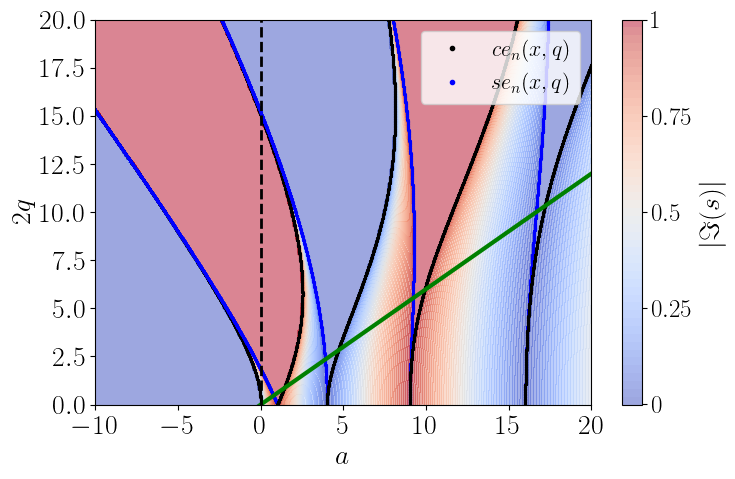

In [52]:
pent = 0.6
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
s0 = eps0*mu0
s1=pent*s0


with open('Map_rho_H12.npy', 'rb') as f:
    aanum = np.load(f)
    qqnum = np.load(f)
    matrho1 = np.load(f)
    matrho2 = np.load(f)
    mats1 = np.load(f)
    mats2 = np.load(f)    

matrho = np.maximum(np.abs(matrho1), np.abs(matrho2))
realsmax = np.maximum(np.real(mats1), np.real(mats2))
#print(realsmax.shape)

mat_row = np.size(aanum)
mat_col = np.size(qqnum)    
    
aanum.shape=(1,mat_row)
qqnum.shape=(1,mat_col)

Mq = np.dot(np.transpose(aanum),np.ones((1,mat_col)))
Mp = np.dot(np.ones((mat_row,1)),qqnum)


imax = 10
listqa = np.ones(imax)
listqb = np.ones(imax)

for ii in range(imax):
    #print(ii)
    [solutiona,solutionb] = solve_mathieu(ii, s0, s1, [2100])
    #[solutiona,solutionb] = solve_mathieu(ii, s0a, s1a, [(s1a/2)*(2*ii+1)**2*test**2*lamba**2/np.pi**2])
    solutiona = solutiona[0]
    solutionb = solutionb[0]
    #[solutiona,solutionb] = solve_with_min(ii, s0a, s1a, (ii*10,1000*ii))
    #[solutiona,solutionb] = solve_with_newton(ii, s0a, s1a, (s1a/2)*(2*ii+1)**2*test**2*lamba**2/np.pi**2)
    #solutiona = solutiona[0]
    #solutionb = solutionb[0]    
    #print(solutiona,solutionb)
    listqa[ii] = solutiona
    listqb[ii] = solutionb
    
print(listqa,listqb)

# Define the range of q values
qq = np.linspace(-50, 50, 10000)
aa = np.linspace(-100, 100, 10000)


# Calculate Mathieu function characteristic values
A0e = [mathieu_a(n, qq) for n in range(5)]  # Even modes
A0o = [mathieu_b(n, qq) for n in range(1, 6)]  # Odd modes

# Set font size for plots
fonty = 20
levelou = np.linspace(0.01,(np.amax(np.asarray(realsmax))),100)
leveli = np.linspace(-0.0001,1+0.0001,50)

fig1 = plt.figure(1, figsize=(8, 5))
plt.rc('text', usetex=True)

# Plot characteristic curves with swapped axes
colors = ['k', 'b']
for i, (a, b) in enumerate(zip(A0e, A0o)):
    plt.plot(a, 2*qq, f'{colors[0]}.', markersize=2.5)
    plt.plot(b, 2*qq, f'{colors[1]}.', markersize=2.5)
    
plt.plot(np.NaN, np.NaN, f'{colors[0]}.', markersize=6., label=r'$ce_n(x,q)$')
plt.plot(np.NaN, np.NaN, f'{colors[1]}.', markersize=6., label=r'$se_n(x,q)$')


#sc = plt.scatter(Mq, Mp, c=realsmax, cmap=plt.cm.coolwarm, s=marker_size, alpha=alphadata)
#sc = plt.contourf(Mq,2*Mp,realsmax, cmap=plt.cm.coolwarm,levels=levelou,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,realsmax, 100,cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2))*(Mq+Mp)/2,100, cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.6)
sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.5)


# Colorbar
cbar = plt.colorbar(sc, format='%.1f')

# Set colorbar label and font size
cbar.set_label(r'$|\Im(s)|$', fontsize=fonty)  # Adjust font size as needed

# Define the tick locations and corresponding labels
tick_locations = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r'$0$', r'$0.25$', r'$0.5$', r'$0.75$', r'$1$']

# Set the ticks and labels
cbar.set_ticks(tick_locations)
cbar.set_ticklabels(tick_labels)

# Set tick parameters for font size
cbar.ax.tick_params(labelsize=fonty-2)  # Adjust font size as needed



# Fill stability regions with swapped axes
#plt.fill_betweenx(2*qq, -100 * np.ones(qq.size), A0e[0], facecolor='b', alpha=0.5)
#for i in range(1, len(A0e)):
#    plt.fill_betweenx(2*qq, A0o[i-1], A0e[i], facecolor='g' if i % 2 else 'b', alpha=0.5)


plt.plot(aa, 2*aa*s1/(2*s0), 'g-',linewidth=3) 
#plt.plot(aa, 2*aa*0.6/2, 'k-',linewidth=2)
plt.plot([0.,0.],[0.,100.], 'k--',linewidth=2) 
#plt.plot([-30.,0.],[30.,0.], 'k--',linewidth=2) 
#plt.plot(aa, -aa*s1/(2*s0), 'k-') 
    
# Customize axes
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$a$', fontsize=fonty)  # x-axis: a
plt.ylabel(r'$2q$', fontsize=fonty)  # y-axis: q
plt.xlim(-10, 20.)
plt.ylim(0.,20.)
#plt.grid()
plt.xscale('linear')
plt.yscale('linear')

# Add legend
plt.legend(fontsize=fonty-4, loc='upper right')

# Show and save the plot
fig1 = plt.gcf()
plt.show()

fig1.savefig('Mathieu_stability_chart_aq_classic.png', format='png', dpi=1000, bbox_inches='tight')

### Floquet eigenvalue computation ($\eta = 0.6$) for Bloch wave plots

Computes the Floquet multipliers `fexp1`, `fexp2` over a frequency sweep
at modulation depth $\eta = 0.6$. Used for the dispersion plots in Fig S6.


In [53]:
# Parameters

TT = np.pi
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
lamb = 1*100e-9
xmax = 10*lamb
s0 = eps0*mu0
#s1 = 0.001*s0
s1=pent*s0

#omega = np.linspace(0.1,10,500)
#aaa = s0*omega**2*lamb**2/np.pi**2
aaa = np.linspace(0.001,25,10000)
qqq = aaa*s1/(2*s0)

fexp1 = np.ones(aaa.size,dtype=complex)
fexp2 = np.ones(aaa.size,dtype=complex)
y_1 = [1., 0.0]
y_2 = [0.0, 1.]
inc = -1
for avis in aaa:
    inc = inc + 1
    # The resolution of the ODE needs to be very accurate DOP853 and Radau seem to do a good job
    #eigenvalues, vecHill = compute_hill_eigenvalues1(avis, qqq[inc], TT)
    eigenvalues = compute_hill_eigenvalues2(avis, qqq[inc], TT)
    fexp1[inc]       = eigenvalues[0]
    fexp2[inc]       = eigenvalues[1]
    #print(fexp1,fexp2)


### → Modulation profile $\varepsilon(x)$ and dispersion — $\eta = 0.6$

Plots the spatial modulation $\varepsilon(x)$ over four periods and
overlays the Floquet-based dispersion curve. Produces `Modulation_positive.png`.


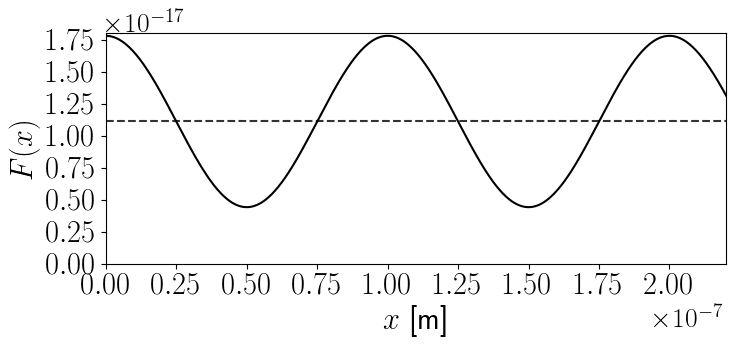

In [54]:
kmax = 1.5e8
vv = 299792458

xplot = np.linspace(0,4*lamb,1000)
yplot = eps0+pent*eps0*np.cos(2*np.pi*xplot/lamb)

fonty = 22
fig1 = plt.figure(1, figsize=(8, 3))
plt.rc('text', usetex=True)

plt.plot(xplot,yplot*mu0,'k-')
#plt.axvline(x=lamb/2+lamb, color='r', linestyle='--', alpha=0.8)
#plt.axvline(x=lamb/2, color='r', linestyle='--', alpha=0.8)
plt.axhline(y=s0, color='k', linestyle='--', alpha=0.8)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$x$ [m]',fontsize=fonty)
plt.ylabel(r'$F(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(0, 2*lamb+lamb/5)   # set the ylim to ymin, ymax
plt.ylim(0.,1.8e-17)   # set the ylim to ymin, ymax
#plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig1 = plt.gcf()
plt.show()

fig1.savefig('Modulation_positive.png', format='png', dpi=1000, bbox_inches='tight')


### → Modulation profile $\varepsilon(x)$ — $\eta = 0.6$ (inset)

Small-format modulation plot used as an inset in Figure S6.
Produces `Modulation_positive.png` (overwrites the $\eta = 0.6$ version above).


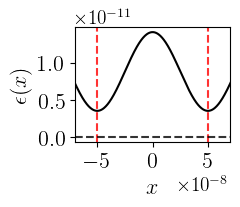

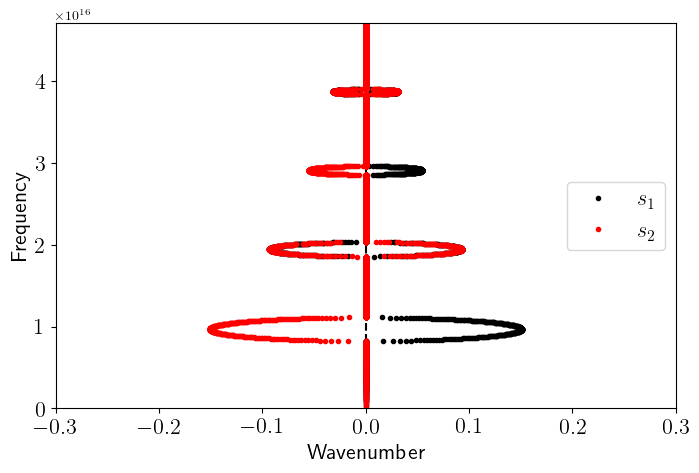

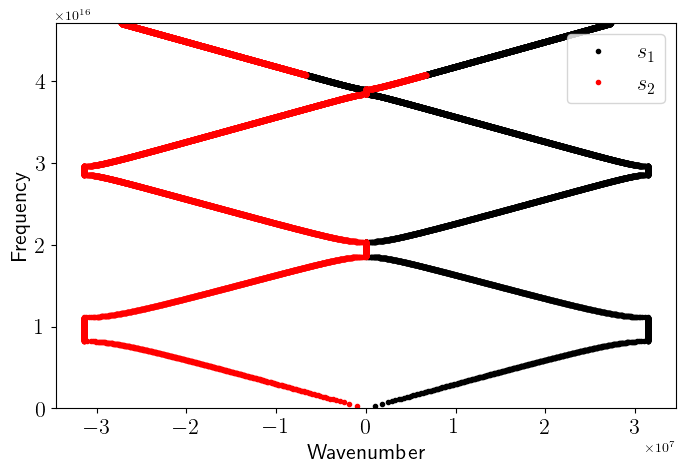

[-15.96837651 -15.94083326 -15.92252788 ...  14.86832727  14.86857412
  14.86882097] [1.00000000e-03 3.50015002e-03 6.00030003e-03 ... 2.49949997e+01
 2.49974998e+01 2.50000000e+01]


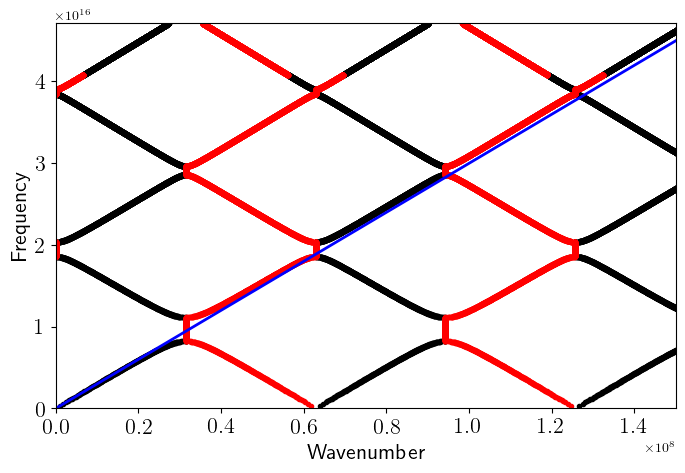

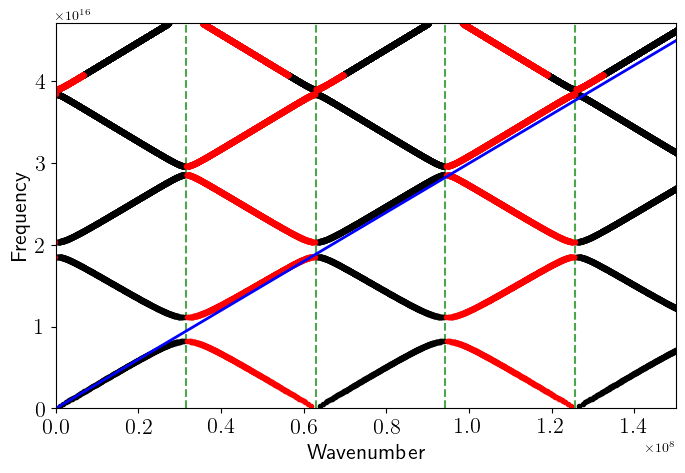

In [55]:
kmax = 1.5e8
vv = 299792458

xplot = np.linspace(-2*lamb,2*lamb,1000)
yplot = eps0+pent*eps0*np.cos(2*np.pi*xplot/lamb)

fonty = 16
fig1 = plt.figure(1, figsize=(2, 1.5))
plt.rc('text', usetex=True)

plt.plot(xplot,yplot,'k-')
plt.axvline(x=-lamb/2, color='r', linestyle='--', alpha=0.8)
plt.axvline(x=lamb/2, color='r', linestyle='--', alpha=0.8)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.8)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$x$',fontsize=fonty)
plt.ylabel(r'$\epsilon(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(-lamb/2-lamb/5, lamb/2+lamb/5)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig1 = plt.gcf()
plt.show()

fig1.savefig('Modulation_positive.png', format='png', dpi=1000, bbox_inches='tight')





fonty = 16
fig3 = plt.figure(3, figsize=(8, 5))

#plt.plot([-0.3, 0.3],[0., 0.],'k--')
plt.plot([0., 0.],[0., np.max(np.pi*np.sqrt(aaa)/np.sqrt(np.abs(s0))/lamb)],'k--')
plt.plot(np.real(fexp1), np.pi*np.sqrt(aaa)/np.sqrt(np.abs(s0))/lamb, 'k.',label=r'$s_1$',linewidth=2.)
plt.plot(np.real(fexp2), np.pi*np.sqrt(aaa)/np.sqrt(np.abs(s0))/lamb, 'r.',label=r'$s_2$',linewidth=2.)
legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel('Wavenumber',fontsize=fonty)
plt.ylabel('Frequency',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(-0.3, 0.3)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., np.max(np.pi*np.sqrt(aaa)/np.sqrt(np.abs(s0))/lamb))   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

#fig3.savefig('Floquet_chart2.png', format='png', dpi=1000,bbox_inches='tight')



fonty = 16
fig3 = plt.figure(3, figsize=(8, 5))

#plt.plot([0,kmax], [0,vv*kmax], 'b-',linewidth=2.)
plt.plot(np.pi*np.imag(fexp1)/lamb, np.pi*np.sqrt(aaa)/np.sqrt(np.abs(s0))/lamb, 'k.',label=r'$s_1$',linewidth=2.)
plt.plot(np.pi*np.imag(fexp2)/lamb, np.pi*np.sqrt(aaa)/np.sqrt(np.abs(s0))/lamb, 'r.',label=r'$s_2$',linewidth=2.)
legend = plt.legend(fontsize=fonty,loc='upper right')
plt.xlabel('Wavenumber',fontsize=fonty)
plt.ylabel('Frequency',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#plt.xlim(xliminf-TT/2., xlimsup-TT/2.)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., np.max(np.pi*np.sqrt(aaa)/np.sqrt(np.abs(s0))/lamb))   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()




shift_range = np.arange(-8, 8)  # Shifts from -3 to 3, including 0
# Generalized concatenation
eigtot1ext = np.concatenate([np.imag(fexp1) + k*2 for k in shift_range])
eigtot2ext = np.concatenate([np.imag(fexp2) + k*2 for k in shift_range])
aaext = np.tile(aaa, len(shift_range))  # Use len() instead of np.length()

print(eigtot1ext, aaext)


fonty = 16
fig3 = plt.figure(3, figsize=(8, 5))

plt.plot(np.pi*eigtot1ext/lamb, np.pi*np.sqrt(aaext)/np.sqrt(np.abs(s0))/lamb, 'k.',linewidth=2.)
plt.plot(np.pi*eigtot2ext/lamb, np.pi*np.sqrt(aaext)/np.sqrt(np.abs(s0))/lamb, 'r.',linewidth=2.)
plt.plot([0,kmax], [0,vv*kmax], 'b-',linewidth=2.)
#legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel('Wavenumber',fontsize=fonty)
plt.ylabel('Frequency',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(0., kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., np.max(np.pi*np.sqrt(aaa)/np.sqrt(np.abs(s0))/lamb))   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()



toto1 = np.where(np.abs(np.real(fexp1))<1e-5)
fexp1sort = fexp1[toto1]
aasort1 = aaa[toto1]
toto2 = np.where(np.abs(np.real(fexp2))<1e-5)
fexp2sort = fexp2[toto2]
aasort2 = aaa[toto2]
aaextsort1 = np.tile(aasort1, len(shift_range))  # Use len() instead of np.length()
aaextsort2 = np.tile(aasort2, len(shift_range))  # Use len() instead of np.length()

eigtot1extsort = np.concatenate([np.imag(fexp1sort) + k*2 for k in shift_range])
eigtot2extsort = np.concatenate([np.imag(fexp2sort) + k*2 for k in shift_range])

num_lines = 5
fonty = 16
fig3 = plt.figure(3, figsize=(8, 5))

# Add vertical dashed lines
for i in range(1, num_lines + 1):
    x_pos = i * np.pi / lamb
    plt.axvline(x=x_pos, color='g', linestyle='--', alpha=0.7)
plt.plot(np.pi*eigtot1extsort/lamb, np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'k.',linewidth=2.)
plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'r.',linewidth=2.)
plt.plot([0,kmax], [0,vv*kmax], 'b-',linewidth=2.)
#legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel('Wavenumber',fontsize=fonty)
plt.ylabel('Frequency',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(0., kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., np.max(np.pi*np.sqrt(aaa)/np.sqrt(np.abs(s0))/lamb))   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

### Bloch wave profiles at three frequencies

Solves the Floquet ODE at three representative angular frequencies and plots
the wave profile $\phi(x)$ and its FFT spectrum:
- $\omega_0 = 0.5 \times 10^{16}$ rad/s — deep pass band
- $\omega_1 = 1.84 \times 10^{16}$ rad/s — Bragg resonance (stop-band edge)
- $\omega_2 = 3.5 \times 10^{16}$ rad/s — deep stop band

Produces `Photonic_omeg0/1/2.png` and `Photonic_omeg0/1/2_FFT.png`.
*(Bloch wave figures appear in Figs S2–S3; this cell is a preliminary step.)*


(-6.323359651256379e-17+0.5355683889329457j) (-6.2405327064266e-17-0.5355683889329457j)
[0.0553497+0.23314926j 0.0553497-0.23314926j]


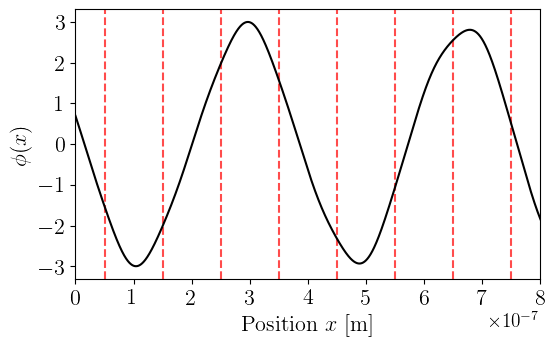

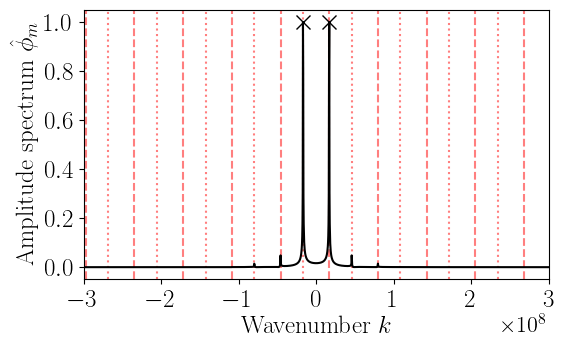

In [56]:
omega0 = 0.5e16
#omega = 1.83802e16     #Bragg
nT = int(200)
nTvisu = 8
y0 = np.array([0.1,-0.2])

nprimary = 1000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest = omega0**2*s0*lamb**2/(np.pi**2)
qtest = atest*s1/(2*s0)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValues, eigenVectors = scipy.linalg.eig(mat_phi)
rho1 = eigenValues[0]
rho2 = eigenValues[1]
eigVector1 = eigenVectors[:,0]
eigVector2 = eigenVectors[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(ff1,ff2)    

#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVectors),y0)
print(cci)

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))

qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),))


solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest, qtest))
q0 = solist.y[0,:]
qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.001, distance=10)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim = np.real(q0)/np.max(peak_amplitudes)
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfund = peak_wavenumbers[indou]

fonty = 16
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(0, nTvisu):
    x_pos = i * lamb + 0.5*lamb
    plt.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)

#plt.plot(listt,np.real(qlist0),'g-',linewidth=1.5)
#plt.plot(listt*lamb/np.pi,np.real(q0),'k-',linewidth=1.5)
plt.plot(listt*lamb/np.pi,q0adim,'k-',linewidth=1.5)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(0, nTvisu*lamb)   # set the ylim to ymin, ymax
plt.xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
plt.ylabel(r'$\phi(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg0.png', format='png', dpi=1000,bbox_inches='tight')



fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-5,5):
    x_pos1 = peak_waveadim0[int(len(peak_waveadim0)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim0[int(len(peak_waveadim0)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='r', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='r', linestyle=':', alpha=0.5)

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim,'k')
plt.plot(peak_waveadim0, peak_ampadim0,'xk',markersize=10)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg0_FFT.png', format='png', dpi=1000,bbox_inches='tight')



(-1.8012120291421145e-16+0.06414412869658749j) (-1.3922821813778009e-16-0.06414412869658752j)
[-0.10065299-0.4396632j -0.10065299+0.4396632j]


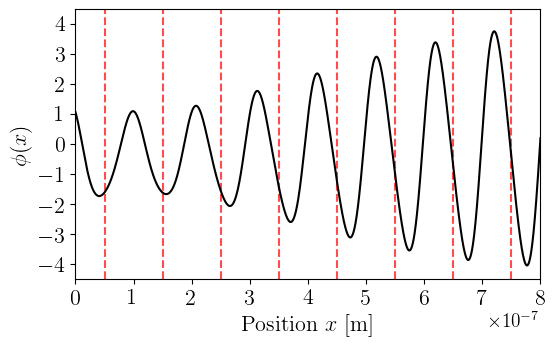

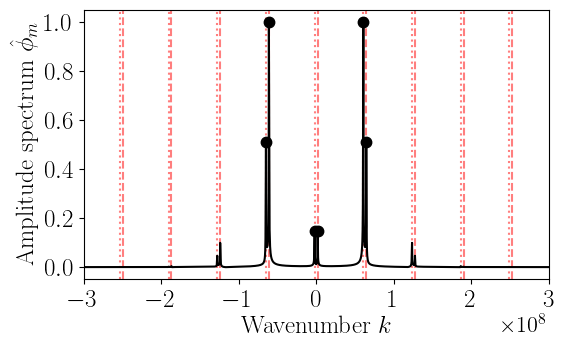

In [57]:
#omega = 1.5e16
omega1 = 1.83802e16     #Bragg
nT = int(200)
nTvisu = 8
y0 = np.array([0.1,-0.2])

nprimary = 1000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest = omega1**2*s0*lamb**2/(np.pi**2)
qtest = atest*s1/(2*s0)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValues, eigenVectors = scipy.linalg.eig(mat_phi)
rho1 = eigenValues[0]
rho2 = eigenValues[1]
eigVector1 = eigenVectors[:,0]
eigVector2 = eigenVectors[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(ff1,ff2)    

#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVectors),y0)
print(cci)

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))

qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),))


solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest, qtest))
q0 = solist.y[0,:]
qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.001, distance=10)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim = np.real(q0)/np.max(peak_amplitudes)
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfund = peak_wavenumbers[indou]

fonty = 16
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(0, nTvisu):
    x_pos = i * lamb + 0.5*lamb
    plt.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)

#plt.plot(listt,np.real(qlist0),'g-',linewidth=1.5)
#plt.plot(listt*lamb/np.pi,np.real(q0),'k-',linewidth=1.5)
plt.plot(listt*lamb/np.pi,q0adim,'k-',linewidth=1.5)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(0, nTvisu*lamb)   # set the ylim to ymin, ymax
plt.xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
plt.ylabel(r'$\phi(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg1.png', format='png', dpi=1000,bbox_inches='tight')



fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-5,5):
    x_pos1 = peak_waveadim1[int(len(peak_waveadim1)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim1[int(len(peak_waveadim1)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='r', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='r', linestyle=':', alpha=0.5)

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim,'k')
plt.plot(peak_waveadim1, peak_ampadim1,'.k',markersize=15)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg1_FFT.png', format='png', dpi=1000,bbox_inches='tight')


(-3.819960189055278e-16+0.38742490164860716j) (-4.947268429056301e-16-0.38742490164860705j)
[-0.10169812-0.27475606j -0.10169812+0.27475606j]


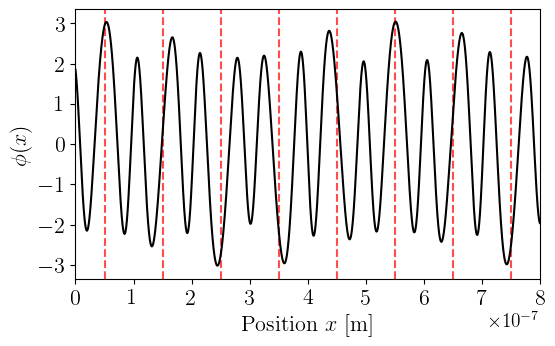

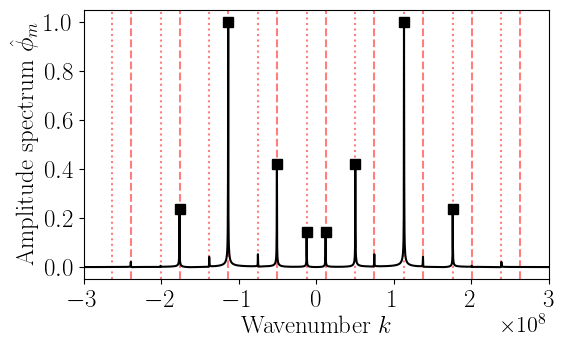

In [58]:
omega2 = 3.5e16
#omega1 = 1.83802e16     #Bragg
nT = int(200)
nTvisu = 8
y0 = np.array([0.1,-0.2])

nprimary = 1000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest = omega2**2*s0*lamb**2/(np.pi**2)
qtest = atest*s1/(2*s0)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValues, eigenVectors = scipy.linalg.eig(mat_phi)
rho1 = eigenValues[0]
rho2 = eigenValues[1]
eigVector1 = eigenVectors[:,0]
eigVector2 = eigenVectors[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(ff1,ff2)    

#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVectors),y0)
print(cci)

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))

qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),))


solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest, qtest))
q0 = solist.y[0,:]
qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.001, distance=10)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim = np.real(q0)/np.max(peak_amplitudes)
peak_waveadim2, peak_ampadim2 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfund = peak_wavenumbers[indou]

fonty = 16
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(0, nTvisu):
    x_pos = i * lamb + 0.5*lamb
    plt.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)

#plt.plot(listt,np.real(qlist0),'g-',linewidth=1.5)
#plt.plot(listt*lamb/np.pi,np.real(q0),'k-',linewidth=1.5)
plt.plot(listt*lamb/np.pi,q0adim,'k-',linewidth=1.5)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(0, nTvisu*lamb)   # set the ylim to ymin, ymax
plt.xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
plt.ylabel(r'$\phi(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg2.png', format='png', dpi=1000,bbox_inches='tight')



fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-5,5):
    x_pos1 = peak_waveadim2[int(len(peak_waveadim2)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim2[int(len(peak_waveadim2)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='r', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='r', linestyle=':', alpha=0.5)

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim,'k')
plt.plot(peak_waveadim2, peak_ampadim2,'sk',markersize=7)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg2_FFT.png', format='png', dpi=1000,bbox_inches='tight')


### → Dispersion relation — extended and fundamental zones

Assembles the Floquet dispersion curve $\omega(k)$ in both the extended
Brillouin zone (all bands) and the reduced (first) zone.
Produces `Dispersion_relation_extended.png` and `Dispersion_relation_fundamental.png`.


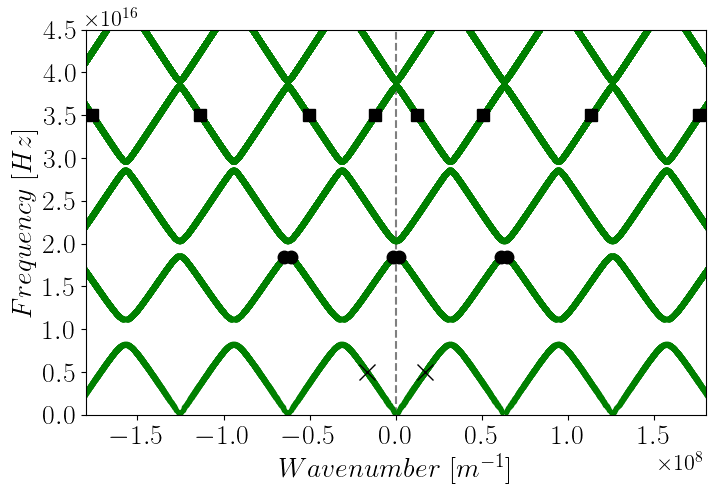

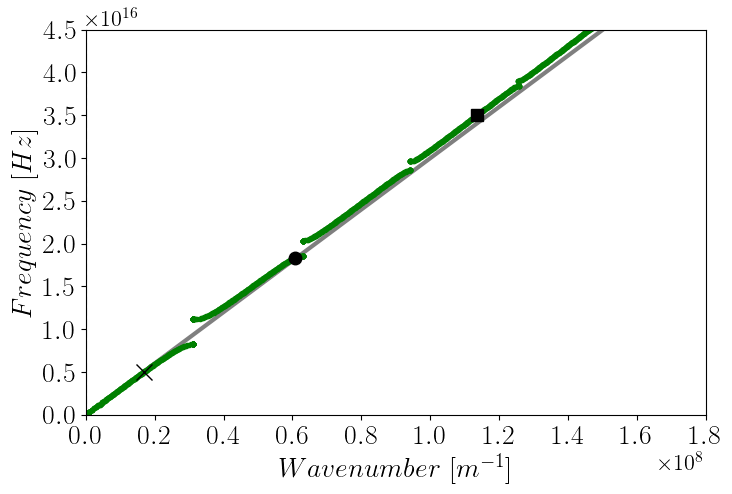

In [59]:
kmax = 1.5e8
ymax = 4.5e16
num_lines = 5
fonty = 20


# Example noisy data
X_noisy = np.concatenate([np.pi*eigtot1extsort/lamb,np.pi*eigtot2extsort/lamb])  # X values
Y_noisy = np.concatenate([np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb,np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb])

# Known line parameters (e.g., Y = mX + c)
m_known = vv*1.02  # Slope of the known line

# Step 1: Define your new set of X values (independently)
X_new = np.linspace(0, kmax, 1000)  # For example, create 100 new X values between 0 and 10

# Step 2: Compute the corresponding Y values for these new X values using the known line
Y_new = m_known * X_new  # Equation of the known line

# Step 3: For each (X_new, Y_new), find the closest point in the noisy data
X_closest = np.zeros(len(X_new))
Y_closest = np.zeros(len(X_new))

for i, (x_new, y_new) in enumerate(zip(X_new, Y_new)):
    # Calculate the distance from (X_new, Y_new) to all points in (X_noisy, Y_noisy)
    distances = np.sqrt((X_noisy - x_new)**2 + (Y_noisy - y_new)**2)
    
    # Find the index of the closest point in the noisy data
    closest_idx = np.argmin(distances)
    
    # Store the closest X and Y values
    X_closest[i] = X_noisy[closest_idx]
    Y_closest[i] = Y_noisy[closest_idx]

distance0 = (Y_closest - omega0)**2
# Find the index of the closest point in the noisy data
closest_idx0 = np.argmin(distance0)
X_closest0 = X_closest[closest_idx0]
Y_closest0 = Y_closest[closest_idx0]

distance1 = (Y_closest - omega1)**2
# Find the index of the closest point in the noisy data
closest_idx1 = np.argmin(distance1)
X_closest1 = X_closest[closest_idx1]
Y_closest1 = Y_closest[closest_idx1]

distance2 = (Y_closest - omega2)**2
# Find the index of the closest point in the noisy data
closest_idx2 = np.argmin(distance2)
X_closest2 = X_closest[closest_idx2]
Y_closest2 = Y_closest[closest_idx2]


fig3 = plt.figure(3, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
# Add vertical dashed lines
for i in range(1, num_lines + 1):
    x_pos = i * np.pi / lamb
    #plt.axvline(x=x_pos, color='g', linestyle='--', alpha=0.7)

plt.plot(np.pi*eigtot1extsort/lamb, np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.)
plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.)
#plt.plot([0,kmax], [0,vv*kmax], 'k-',linewidth=3.,alpha=0.5)
plt.plot(peak_waveadim2, omega2*np.ones(peak_waveadim2.size),'sk',markersize=8)
plt.plot(peak_waveadim1, omega1*np.ones(peak_waveadim1.size),'.k',markersize=18)
plt.plot(peak_waveadim0, omega0*np.ones(peak_waveadim0.size),'xk',markersize=12)
#legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel(r'$Wavenumber$ $[m^{-1}]$',fontsize=fonty)
plt.ylabel(r'$Frequency$ $[Hz]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)
ax.yaxis.get_offset_text().set_fontsize(fonty-4)

plt.xlim(-1.2*kmax, 1.2*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

fig3.savefig('Dispersion_relation_extended.png', format='png', dpi=1000, bbox_inches='tight')



fig4 = plt.figure(4, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
# Add vertical dashed lines
for i in range(1, num_lines + 1):
    x_pos = i * np.pi / lamb
    #plt.axvline(x=x_pos, color='g', linestyle='--', alpha=0.7)

#plt.plot(np.pi*eigtot1extsort/lamb, np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.)
#plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.)
plt.plot([0,kmax], [0,vv*kmax], 'k-',linewidth=3.,alpha=0.5)
plt.plot(X_closest, Y_closest, 'g.',linewidth=1.)
plt.plot(X_closest2, Y_closest2,'sk',markersize=8)
plt.plot(X_closest1, Y_closest1,'.k',markersize=18)
plt.plot(X_closest0, Y_closest0,'xk',markersize=12)

#legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel(r'$Wavenumber$ $[m^{-1}]$',fontsize=fonty)
plt.ylabel(r'$Frequency$ $[Hz]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)
ax.yaxis.get_offset_text().set_fontsize(fonty-4)

plt.xlim(0, 1.2*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig4 = plt.gcf()
plt.show()

fig4.savefig('Dispersion_relation_fundamental.png', format='png', dpi=1000, bbox_inches='tight')







### Finite periodic slab solver

Defines `solve_slab_positive()`: integrates the Hill ODE over $m$ periods
with Dirichlet boundary conditions to find the stationary eigenfrequencies
and mode shapes of a finite classical box.


In [60]:
"""
m‑modes‑per‑band solver for a finite periodic slab
==================================================

Solves  −Φ'' = omega² F(x) Φ   with Dirichlet walls at x=0, x=L=m·λ,
groups the eigenpairs into pass‑bands (m modes per band),
prints the modal frequencies per band, and draws every mode
in the first pass‑band.

Only NumPy (+ Matplotlib for the optional plot) is required.
"""

import numpy as np
from numpy.linalg import eigh
import matplotlib.pyplot as plt   # only for the demonstration plot


# ---------------------------------------------------------------------
# core routine
# ---------------------------------------------------------------------
def slab_modes_grouped(C0, C1, lam,
                       m, ppp,
                       n_bands):
    """
    Parameters
    ----------
    C0, C1 : float
        Background and modulation of F(x) = C0 + C1 cos(2πx/λ).
    lam        : float
        Period λ of the medium.
    m          : int
        Number of periods between the two Dirichlet walls.  L = m·λ.
    ppp        : int
        Grid points per period (≥ ~200 for good accuracy).
    n_bands    : int
        How many pass‑bands to keep (⇒ n_bands*m eigenpairs).

    Returns
    -------
    x          : (N,) grid (includes the two boundaries)
    o0_bands   : list[ (m,) ]     free‑space frequency per band
    Phi_bands  : list[ (N,m) ]    eigenfunctions per band, normalised
                                  so that ∫ε Φ_n Φ_m dx = δ_nm.
    """
    # ---------------- grid & material profile --------------------------
    Nx  = m*ppp + 1                        # include end points
    print(Nx)
    x   = np.linspace(0.0, m*lam, Nx)
    dx  = x[1] - x[0]
    FFF = C0 + C1*np.cos(2.0*np.pi*x/lam)

    # ---------------- assemble stiffness & mass ------------------------
    Nint = Nx - 2                         # interior nodes only
    main =  2.0*np.ones(Nint)   / dx**2
    off  = -1.0*np.ones(Nint-1) / dx**2
    T    = np.diag(main) + np.diag(off,1) + np.diag(off,-1)   # stiffness
    M    = np.diag(FFF[1:-1])                                     # mass

    # ---------------- convert to standard eigen‑problem ----------------
    Minv_sqrt = np.diag(1.0/np.sqrt(FFF[1:-1]))
    A = Minv_sqrt @ T @ Minv_sqrt        # symmetric, real

    need = n_bands * m
    eigi, vec = eigh(A)                   # full solve (dense)
    eigi, vec = eigi[:need], vec[:, :need]

    # ---------------- back‑transform eigenvectors ----------------------
    Phi_int = Minv_sqrt @ vec
    Phi = np.zeros((Nx, need))
    Phi[1:-1, :] = Phi_int

    # ---------------- ε‑weighted L² normalisation ----------------------
    w = FFF[:, None]
    Phi /= np.sqrt(np.trapz(w*Phi**2, x, axis=0))

    o0 = np.sqrt(eigi)                   # free‑space wavenumbers
    
    # ---------- orthonormality check -----------------------------------
    
    S = np.trapz(FFF[:,None,None]*Phi[:,:,None]*Phi[:,None,:], x, axis=0)
    print("max |S_nn−1| =", np.max(np.abs(np.diag(S)-1)))
    print("max |S_nm| (n≠m) =", np.max(np.abs(S-np.diag(np.diag(S)))))    
    
    #S = np.trapz(Phi[:, :, None] * Phi[:, None, :], x, axis=0)
    #print("max |S_nn−1| =", np.max(np.abs(np.diag(S))))
    #print("max |S_nm| (n \neq m) =", np.max(np.abs(S - np.diag(np.diag(S)))))

    # ---------------- split into consecutive blocks of length m --------
    o0_bands  = [o0[i*m:(i+1)*m]        for i in range(n_bands)]
    Phi_bands = [Phi[:, i*m:(i+1)*m]    for i in range(n_bands)]

    return x, o0_bands, Phi_bands


### → Figures S5a and S7 — One-wavelength classical box ($L = \lambda$)

Computes stationary mode shapes and eigenfrequency ladder for $L = \lambda$
(one period, $m = 1$ mode per pass band).
- `Modesfinite_classic_onefullbox.png` — mode profiles → **Fig S5a**
- `Evol_disp_classic_onewavelength_inabox.png` — dispersion evolution → **Fig S5a**
- `Energy_evol_classic_onewavelength_inabox.png` — energy in box → **Fig S7**


401
max |S_nn−1| = 1.2212453270876722e-15
max |S_nm| (n≠m) = 5.434771309702362e-16
[array([8.23400736e+15]), array([1.8569306e+16]), array([2.85766669e+16]), array([3.84258339e+16])]
Periodic slab: C0 = 1.1126264540484579e-17,  C1 = -6.675758724290747e-18,  λ = 1e-07
Pass‑band  1:  o0 = [8234007362549573.00000]
Pass‑band  2:  o0 = [18569305998573848.00000]
Pass‑band  3:  o0 = [28576666903636972.00000]
Pass‑band  4:  o0 = [38425833924904800.00000]


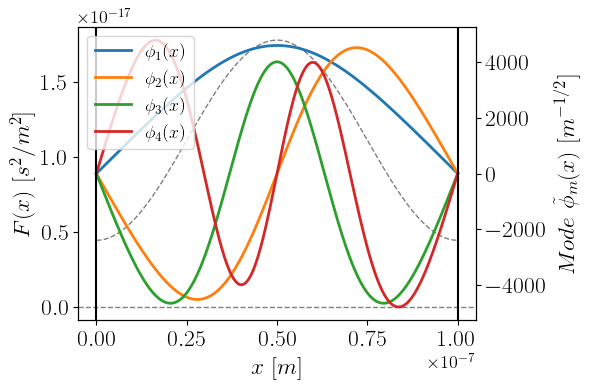

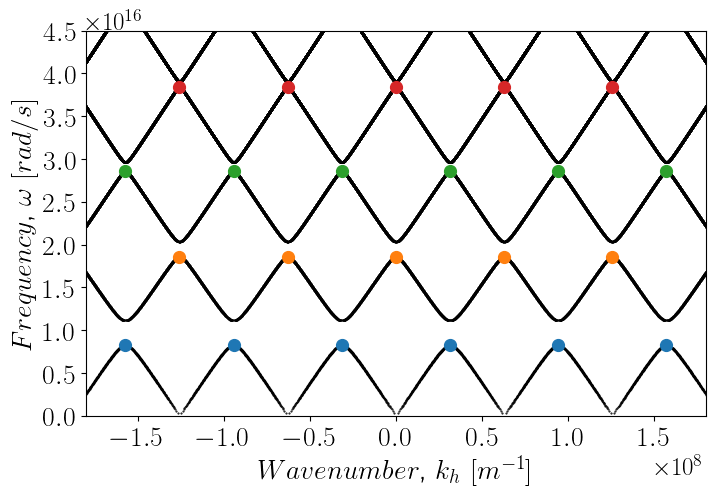

eig residual (rel inf) after L2 rescale = 7.414e-12
[1.21447547e-16 5.38523088e-17 3.49935842e-17 2.60241587e-17]
[3.17328240e-08 1.56985934e-08 1.06103882e-08 8.04557504e-09]
||u_eps - u_L2|| / ||u_eps|| = 1.304874330605673e-16
[1.21447547e-16 5.38523088e-17 3.49935842e-17 2.60241587e-17]
[Energy check] max|E_modal - E_quad| / E0 = 9.534e-14
[Energy check] rel variation of E_quad   = 4.800e-13
E per selected mode at t=0: [2.92947670e-08 2.35351606e-08 2.17542595e-08 2.09251805e-08]
S_nn for selected modes   : [5.85895340e-08 4.70703212e-08 4.35085190e-08 4.18503611e-08]


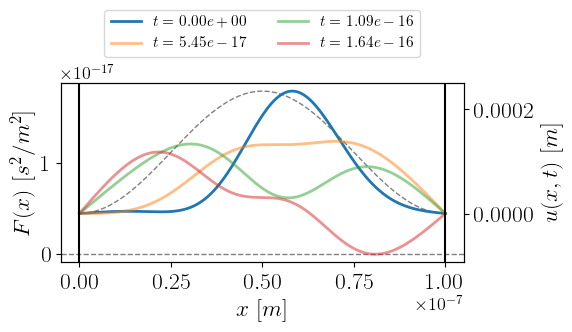

9.550936760647227e-08


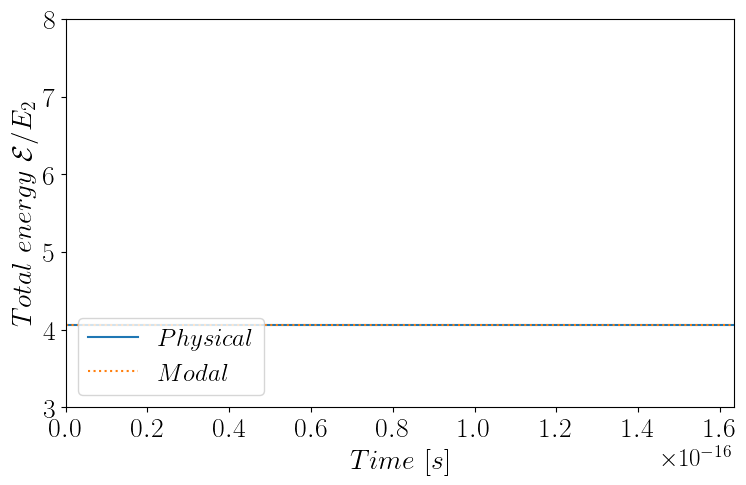

0
1
2
3


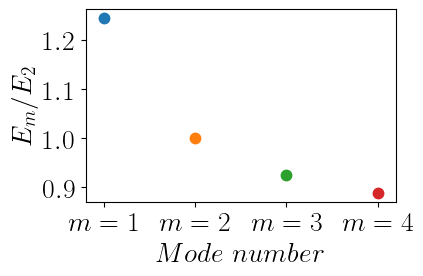

[1. 1. 1. 1.]


In [61]:
from matplotlib.ticker import ScalarFormatter



# ---------------------------------------------------------------------
# demonstration (m = n_bands = 4)
# ---------------------------------------------------------------------
if __name__ == "__main__":
    # ---- physical parameters -----------------------------------------
    eps0 = 8.854e-12
    mu0 = 1.25663706127e-6
    C0, C1 = eps0*mu0, -0.6*eps0*mu0    # fixed medium
#    C0, C1 = eps0*mu0, -0.01*eps0*mu0    # fixed medium
    lam        = 100e-9           # period
    m          = 1             # modes per band
    n_bands    = 4             # number of pass‑bands to keep
    ppp        = 400           # grid density

    # ---- compute ------------------------------------------------------
    x, o0_bands, Phi_bands = slab_modes_grouped(C0, C1, lam,
                                                m, ppp, n_bands)
    print(o0_bands)
    # ---- print nice summary ------------------------------------------
    print(f"Periodic slab: C0 = {C0},  C1 = {C1},  λ = {lam}")
    for b, olist in enumerate(o0_bands, start=1):
        txt = ", ".join(f"{oo:.5f}" for oo in olist)
        print(f"Pass‑band {b:>2d}:  o0 = [{txt}]")



# --- Plot first N modes along with F(x) on a twin y-axis
N = 4  # Number of modes to plot
FFF = C0 + C1 * np.cos(2 * np.pi * x / lam)  # Material profile (same as inside function)

fonty = 17
fig, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)

# Plot the first N modes from flattened Phi_bands
Phi_eps = np.hstack(Phi_bands)  # shape: (Nx, total_modes)
omega   = np.concatenate(o0_bands)      # (K,)
Nx, K   = Phi_eps.shape
#for n in range(N):
#    ax1.plot(x, Phi_all[:, n], label=f"Mode {n+1}", linewidth=2)

# ---------- Make an L2-rescaled copy (per column only) ----------
# Use simple trapz for L2; (optionally) trapezoid weights W if you prefer.
l2 = np.sqrt(np.trapz(Phi_eps**2, x, axis=0))   # shape (K,)
Phi_L2 = Phi_eps / l2                           # still exact eigenvectors


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
for n in range(N):
    line, = ax1.plot(x, Phi_L2[:, n], label=fr"$\phi_{n+1}(x)$", linewidth=2)
    lines.append(line)
    
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$Mode$ $\tilde{\phi}_m(x)$ $[m^{-1/2}]$', fontsize=fonty)
ax1.legend(loc="upper left",fontsize=fonty-4)
ax1.set_xlim(-100e-9*0.05, 100e-9+100e-9*0.05)

# Set font size for the offset text
#ax1 = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)


#ax = plt.gca()
#ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
#ax.xaxis.get_offset_text().set_fontsize(fonty)  # adjust size of 10^ exponent

# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(m*lam, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()


fig.savefig('Modesfinite_classic_onefullbox.png', format='png', dpi=1000, bbox_inches='tight')





fonty = 20
fig3 = plt.figure(3, figsize=(8, 5))
plt.rc('text', usetex=True)

#plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
# Add vertical dashed lines
for i in range(1, num_lines + 1):
    x_pos = i * np.pi / lamb
    #plt.axvline(x=x_pos, color='g', linestyle='--', alpha=0.7)

plt.plot(np.pi*eigtot1extsort/lamb, np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'k.',markersize=1.,alpha=1)
plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'k.',markersize=1.,alpha=1)
#plt.plot([0,kmax], [0,vv*kmax], 'k-',linewidth=3.,alpha=0.5)
#legend = plt.legend(fontsize=fonty,loc='right')
for b, olist in enumerate(o0_bands, start=0):
    for oo in olist:
        color = lines[b % len(lines)].get_color()
        if b % 2:  # odd band index
            kkkk = 0 + (2*np.pi/lam) * np.array([-3,-2,-1,0,1,2,3])
        else:      # even band index
            kkkk = np.pi/lam + (2*np.pi/lam) * np.array([-3,-2,-1,0,1,2,3])
        yyyy = np.full_like(kkkk, oo, dtype=float)
        plt.plot(kkkk, yyyy, '.', markersize=17, color=color, alpha=1)


        
plt.xlabel(r'$Wavenumber$, $k_h$ $[m^{-1}]$',fontsize=fonty)
plt.ylabel(r'$Frequency$, $\omega$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-1.2*kmax, 1.2*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

fig3.savefig('Dispersion_relation_extended_plus_modes_1.png', format='png', dpi=1000, bbox_inches='tight')









# (Sanity) M-orthogonality off-diagonals stay ~0; diagonals are not ±1 anymore
Mmat    = np.diag(FFF[1:-1])
Phi_int = Phi_L2[1:-1, :]
S = Phi_int.T @ (Mmat @ Phi_int)                # Φᵀ M Φ   (K,K)
# Build T on interior exactly as in your solver
dx   = x[1] - x[0]
Nint = Phi_int.shape[0]
main =  2.0*np.ones(Nint)/dx**2
off  = -1.0*np.ones(Nint-1)/dx**2
Tmat = np.diag(main) + np.diag(off,1) + np.diag(off,-1)
Kmat = Phi_int.T @ (Tmat  @ Phi_int)            # Φᵀ T Φ   (K,K)

# (Optional) verify eigen relation still holds (it does; scaling doesn’t change it)
res = Tmat @ Phi_int - Mmat @ (Phi_int * (omega**2))
rel_inf = np.linalg.norm(res, np.inf) / (np.linalg.norm(Tmat @ Phi_int, np.inf) + 1e-300)
print("eig residual (rel inf) after L2 rescale =", f"{rel_inf:.3e}")



# ---------- Choose initial modal amplitudes using L2 interpretation ----------
# --- Choose initial modal amplitudes q(0)
u0 = 1*(Phi_eps[:, 0]/omega[0]+Phi_eps[:, 1]/omega[1]+Phi_eps[:, 2]/omega[2] + Phi_eps[:, 3]/omega[3])
#u0 = 1*(Phi_eps[:, 0]/omega[0]+ Phi_eps[:, 3]/omega[3])
q_eps = np.trapz(FFF[:, None] * u0[:, None] * Phi_eps, x, axis=0)
print(q_eps)
qL2 = q_eps * l2                               # D^{-1} q_eps
print(qL2)

# Field consistency check
u_from_eps = Phi_eps @ q_eps
u_from_L2  = Phi_L2  @ (l2 * q_eps)    # must match u_from_eps
print("||u_eps - u_L2|| / ||u_eps|| =",
      np.linalg.norm(u_from_eps - u_from_L2) / (np.linalg.norm(u_from_eps) + 1e-300))


# Example: equal-energy-by-displacement: q_n(0) = 1/ω_n (you can choose any rule)
q0  = np.zeros(K)
pick = [0,1,2, 3] # modes you want
q0[pick] = 1.0 / omega[pick]
print(q0)
dq0 = np.zeros_like(q0)

# ---------- Reconstruct fields and compute energy (normalization-agnostic) ----------
# Time evolution (decoupled cosines) is valid since columns are still eigenvectors
Tfinal = 2*np.pi/np.max(omega)
Nt = 1000
t  = np.linspace(0.0, Tfinal, Nt)
q  = q0 * np.cos(np.outer(t, omega))            # (Nt,K)
dq = -q0 * omega * np.sin(np.outer(t, omega))   # (Nt,K)
qL2  = qL2 * np.cos(np.outer(t, omega))            # (Nt,K)
dqL2 = -qL2 * omega * np.sin(np.outer(t, omega))   # (Nt,K)

# Energy via general modal form (works for ANY normalization)
E_modal = 0.5 * (np.einsum('ti,ij,tj->t', dq, S, dq) +
                 np.einsum('ti,ij,tj->t',  q, Kmat, q))

# (Cross-check) energy via physical-space quadratic form
u  = q @ Phi_eps.T                                      # (Nt, Nx)
ut = dq @ Phi_eps.T                                     # (Nt, Nx)
uL2  = qL2 @ Phi_L2.T                                      # (Nt, Nx)
utL2 = dqL2 @ Phi_L2.T                                     # (Nt, Nx)
u_int  = q  @ Phi_int.T
ut_int = dq @ Phi_int.T
E_quad = 0.5 * (np.einsum('ti,ij,tj->t', ut_int, Mmat, ut_int) +
                np.einsum('ti,ij,tj->t',  u_int,  Tmat,  u_int))


E0 = E_quad[0]
print(f"[Energy check] max|E_modal - E_quad| / E0 = {np.max(np.abs(E_modal - E_quad))/E0:.3e}")
print(f"[Energy check] rel variation of E_quad   = {np.ptp(E_quad)/E0:.3e}")

# ---------- Per-mode energy at t=0 (with dq0=0) ----------
# For exact eigenvectors: Kmat ≈ S @ diag(ω^2), so E_n(0) ≈ 0.5 * S_nn * (1)
E_modes_0 = 0.5 * (q0**2) * np.diag(Kmat)
print("E per selected mode at t=0:", E_modes_0[pick])
print("S_nn for selected modes   :", np.diag(S)[pick])

fonty = 17
fig1, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
snap_idx = np.linspace(0, Nt-1, 4, dtype=int)
for si in snap_idx:
    if si < 1:
        line, = ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2)
        lines.append(line)
    else:
        line, = ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2,alpha=0.5)
        lines.append(line)
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$u(x,t)$ $[m]$', fontsize=fonty)
#ax1.legend(loc="upper left",fontsize=fonty-6)
ax1.legend(loc='upper center',
    bbox_to_anchor=(0.5, 1.45),
    ncol=2,fontsize=fonty-6)
ax1.set_xlim(-100e-9*0.05, 100e-9+100e-9*0.05)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)


# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(m*lam, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig1.savefig('Evol_disp_classic_onewavelength_inabox.png', format='png', dpi=1000, bbox_inches='tight')



print(E0)
# -- Plots
fonty = 20
fig5 = plt.figure(5, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.plot(t, E_quad/E_modes_0[1],           label=r'$Physical$')
plt.plot(t, E_modal/E_modes_0[1], ':', label=r'$Modal$')

plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$Time$ $[s]$',fontsize=fonty)
plt.ylabel(r'$Total$ $energy$ $\mathcal{E}/E_2$',fontsize=fonty)
plt.legend(loc="lower left",fontsize=fonty-2); 
plt.tight_layout()
plt.xlim(0,t[-1])
plt.ylim(3,8)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.show()


fig5.savefig('Energy_evol_classic_onewavelength_inabox.png', format='png', dpi=1000, bbox_inches='tight')



fonty = 20
fig4 = plt.figure(4, figsize=(4, 2.5))
plt.rc('text', usetex=True)


#plt.axhline(y=E_modes_0[-1]/lam,color="black", lw=1.,linestyle='--')
#plt.plot(pick,E_modes_0[pick]/100e-9,'.',markersize=15)  
flat_array = np.concatenate(o0_bands)  # shape: (total_modes,)
for b, oo in enumerate(flat_array[0:N],start=0):
    if b < N:
        print(b)
        color = lines[b].get_color()  # match mode color
        plt.plot(b,E_modes_0[b]/E_modes_0[1],'.',markersize=15., alpha=1,color=color)

#plt.legend(loc="center right",fontsize=fonty-6)    
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$E_m/E_2$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-0.2, 3.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(0.85, 1.2)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1,2, 3], [r'$m=1$',r'$m=2$',r'$m=3$',r'$m=4$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Energy_per_mode_evol_classic_onewavelength_inabox.png', format='png', dpi=1000, bbox_inches='tight')



print(np.sqrt(np.trapz(Phi_L2**2, x, axis=0)))

### → Figure S5 — Half-wavelength classical box ($L = \lambda/2$)

Same analysis for $L = \lambda/2$.
Produces `Modesfinite_classic_halffullbox.png` and
`Dispersion_relation_extended_plus_mode2.png`.


401
max |S_nn−1| = 9.992007221626409e-16
max |S_nm| (n≠m) = 5.356846396137335e-16
[array([1.64680147e+16]), array([3.7138612e+16]), array([5.71533338e+16]), array([7.68516678e+16])]
Periodic slab: C0 = 1.1126264540484579e-17,  C1 = -6.675758724290747e-18,  λ = 5e-08
Pass‑band  1:  o0 = [16468014725099146.00000]
Pass‑band  2:  o0 = [37138611997147696.00000]
Pass‑band  3:  o0 = [57153333807273944.00000]
Pass‑band  4:  o0 = [76851667849809600.00000]


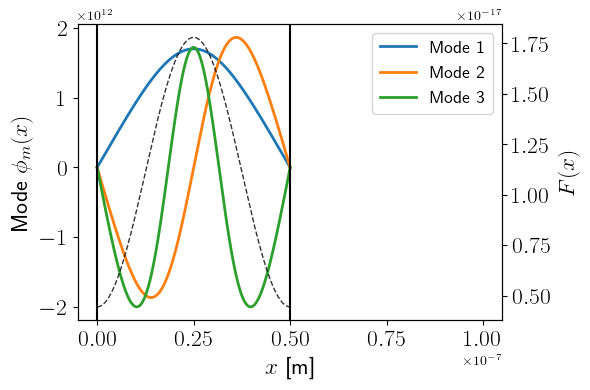

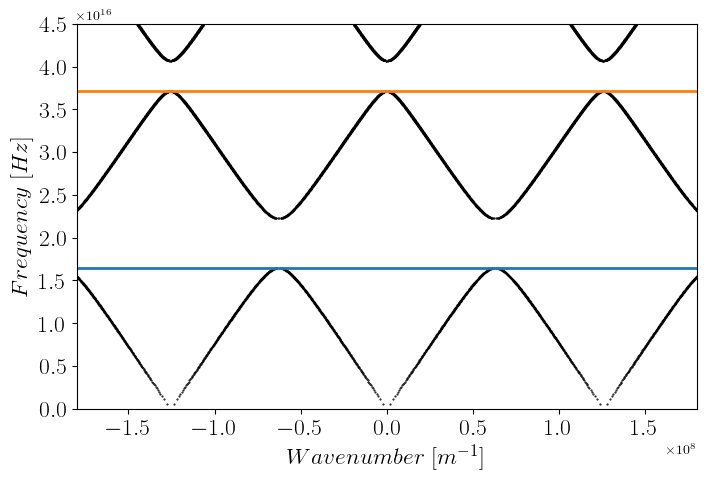

In [62]:
# ---------------------------------------------------------------------
# demonstration (m = n_bands = 4)
# ---------------------------------------------------------------------
if __name__ == "__main__":
    # ---- physical parameters -----------------------------------------
    eps0 = 8.854e-12
    mu0 = 1.25663706127e-6
    C0, C1 = eps0*mu0, -0.6*eps0*mu0    # fixed medium
    lam        = 100e-9/2           # period
    m          = 1             # modes per band
    n_bands    = 4             # number of pass‑bands to keep
    ppp        = 400           # grid density

    # ---- compute ------------------------------------------------------
    x, o0_bands, Phi_bands = slab_modes_grouped(C0, C1, lam,
                                                m, ppp, n_bands)
    print(o0_bands)
    # ---- print nice summary ------------------------------------------
    print(f"Periodic slab: C0 = {C0},  C1 = {C1},  λ = {lam}")
    for b, olist in enumerate(o0_bands, start=1):
        txt = ", ".join(f"{oo:.5f}" for oo in olist)
        print(f"Pass‑band {b:>2d}:  o0 = [{txt}]")
        
        
        
        
        
from matplotlib.ticker import ScalarFormatter



# --- Plot first N modes along with F(x) on a twin y-axis
N = 4  # Number of modes to plot
FFF = C0 + C1 * np.cos(2 * np.pi * x / lam)  # Material profile (same as inside function)

fonty = 17
fig, ax1 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)

# Plot the first N modes from flattened Phi_bands
Phi_all = np.hstack(Phi_bands)  # shape: (Nx, total_modes)
#for n in range(N):
#    ax1.plot(x, Phi_all[:, n], label=f"Mode {n+1}", linewidth=2)

    
# Store plotted lines to extract their colors
lines = []
for n in range(N-1):
    line, = ax1.plot(x, Phi_all[:, n], label=f"Mode {n+1}", linewidth=2)
    lines.append(line)
    
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax1.set_xlabel(r'$x$ [m]', fontsize=fonty)
ax1.set_ylabel(r'Mode $\phi_m(x)$', fontsize=fonty)
ax1.legend(loc="upper right",fontsize=fonty-4)
ax1.set_xlim(-100e-9*0.05, 100e-9+100e-9*0.05)


# Twin axis for F(x)
ax2 = ax1.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.8, label="Material profile $F(x)$")
ax2.set_ylabel(r"$F(x)$", fontsize=fonty)
#ax2.legend(loc="upper left")

#ax = plt.gca()
#ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
#ax.xaxis.get_offset_text().set_fontsize(fonty)  # adjust size of 10^ exponent

# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(m*lam, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()


fig.savefig('Modesfinite_classic_halffullbox.png', format='png', dpi=1000, bbox_inches='tight')



fig3 = plt.figure(3, figsize=(8, 5))
plt.rc('text', usetex=True)

#plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
# Add vertical dashed lines
for i in range(1, num_lines + 1):
    x_pos = i * np.pi / lamb
    #plt.axvline(x=x_pos, color='g', linestyle='--', alpha=0.7)

plt.plot(2*np.pi*eigtot1extsort/lamb, 2*np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'k.',markersize=1.,alpha=1)
plt.plot(2*np.pi*eigtot2extsort/lamb, 2*np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'k.',markersize=1.,alpha=1)
#plt.plot([0,kmax], [0,vv*kmax], 'k-',linewidth=3.,alpha=0.5)
#legend = plt.legend(fontsize=fonty,loc='right')
for b, olist in enumerate(o0_bands, start=0):
    #print(b)
    for oo in olist:
        if b < N-1:
            color = lines[b].get_color()  # match mode color
            plt.axhline(y=oo, linestyle='-',linewidth=2., alpha=1,color=color)
        else:
            plt.axhline(y=oo, linestyle='-',linewidth=2., alpha=1,color='tab:red')
        
        
plt.xlabel(r'$Wavenumber$ $[m^{-1}]$',fontsize=fonty)
plt.ylabel(r'$Frequency$ $[Hz]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)


plt.xlim(-1.2*kmax, 1.2*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

fig3.savefig('Dispersion_relation_extended_plus_mode2.png', format='png', dpi=1000, bbox_inches='tight')



### → Figures S5 and S7 — Two-half-wavelength classical box ($L = \lambda$, $P = 2$)

Box containing two half-wavelength cells ($P = 2$). Shows doubled eigenfrequency count.
- `Modesfinite_classic_twohalffullbox.png` — mode profiles → **Fig S5**
- `Evol_disp_classic_twowavelengths_inabox.png` — dispersion evolution → **Fig S5**
- `Energy_evol_classic_twowavelengths_inabox.png` — energy in box → **Fig S7**


401
max |S_nn−1| = 1.3322676295501878e-15
max |S_nm| (n≠m) = 7.247047666491895e-16
[array([9.34957213e+15, 1.64678807e+16]), array([2.93306889e+16, 3.71373419e+16]), array([4.86165774e+16, 5.71488161e+16]), array([6.78411848e+16, 7.68407773e+16])]
Periodic slab: C0 = 1.1126264540484579e-17,  C1 = -6.675758724290747e-18,  λ = 5e-08
Pass‑band  1:  o0 = [9349572131383536.00000, 16467880698816944.00000]
Pass‑band  2:  o0 = [29330688939430876.00000, 37137341861793848.00000]
Pass‑band  3:  o0 = [48616577435924080.00000, 57148816112447728.00000]
Pass‑band  4:  o0 = [67841184768148032.00000, 76840777295262000.00000]


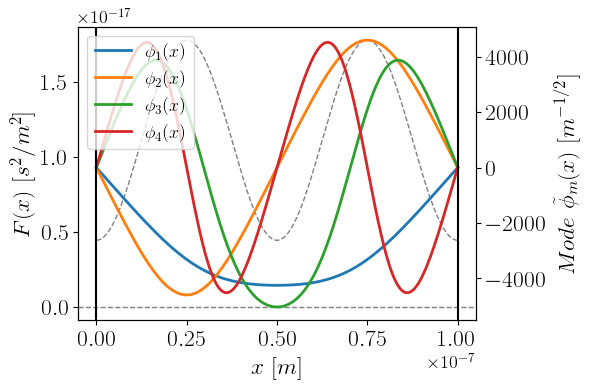

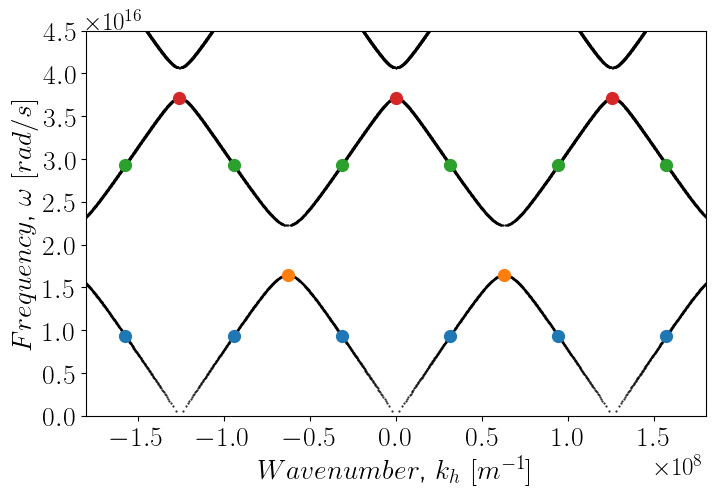

eig residual (rel inf) after L2 rescale = 2.311e-12
[ 1.06956766e-16  6.07242679e-17  3.40939827e-17  2.69270753e-17
  5.11812933e-32 -4.10256903e-32 -1.02763078e-31  2.18109832e-32]
[ 3.16026250e-08  1.58665280e-08  1.08935826e-08  7.84951454e-09
  1.64175387e-23 -1.24391434e-23 -3.28279721e-23  6.74278731e-24]
||u_eps - u_L2|| / ||u_eps|| = 1.2026050634491817e-16
[1.06956766e-16 6.07242679e-17 3.40939827e-17 2.69270753e-17
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
[Energy check] max|E_modal - E_quad| / E0 = 1.073e-13
[Energy check] rel variation of E_quad   = 1.018e-12
E per selected mode at t=0: [2.29086875e-08 2.92948154e-08 1.95904317e-08 2.35354642e-08]
S_nn for selected modes   : [4.58173749e-08 5.85896308e-08 3.91808634e-08 4.70709284e-08]


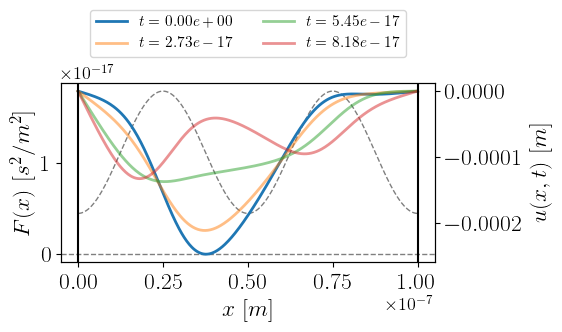

9.532939874451384e-08


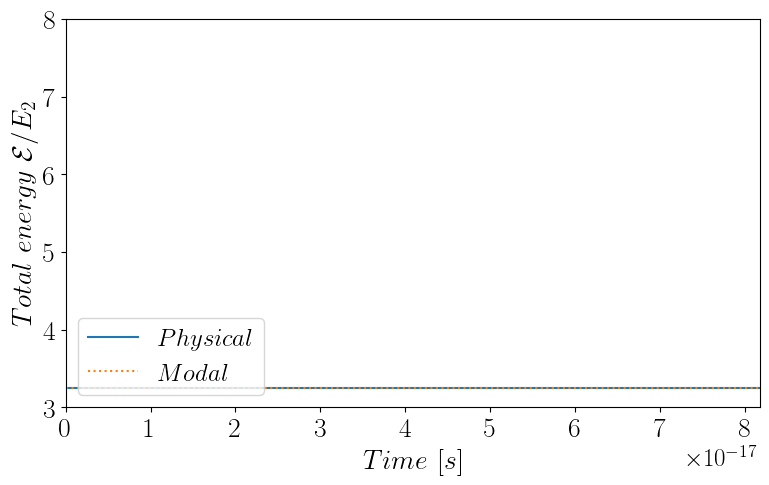

0
1
2
3


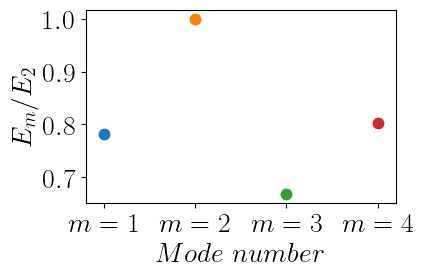

[1. 1. 1. 1. 1. 1. 1. 1.]


In [63]:
# ---------------------------------------------------------------------
# demonstration (m = n_bands = 4)
# ---------------------------------------------------------------------
if __name__ == "__main__":
    # ---- physical parameters -----------------------------------------
    eps0 = 8.854e-12
    mu0 = 1.25663706127e-6
    C0, C1 = eps0*mu0, -0.6*eps0*mu0    # fixed medium
#    C0, C1 = eps0*mu0, -0.01*eps0*mu0    # fixed medium    
    lam        = 100e-9/2           # period
    m          = 2             # modes per band
    n_bands    = 4             # number of pass‑bands to keep
    ppp        = 200           # grid density

    # ---- compute ------------------------------------------------------
    x, o0_bands, Phi_bands = slab_modes_grouped(C0, C1, lam,
                                                m, ppp, n_bands)
    print(o0_bands)
    # ---- print nice summary ------------------------------------------
    print(f"Periodic slab: C0 = {C0},  C1 = {C1},  λ = {lam}")
    for b, olist in enumerate(o0_bands, start=1):
        txt = ", ".join(f"{oo:.5f}" for oo in olist)
        print(f"Pass‑band {b:>2d}:  o0 = [{txt}]")
        
        
        
        
        
from matplotlib.ticker import ScalarFormatter



# --- Plot first N modes along with F(x) on a twin y-axis
N = 4  # Number of modes to plot
FFF = C0 + C1 * np.cos(2 * np.pi * x / lam)  # Material profile (same as inside function)

fonty = 17
fig, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)

# Plot the first N modes from flattened Phi_bands
Phi_eps = np.hstack(Phi_bands)  # shape: (Nx, total_modes)
omega   = np.concatenate(o0_bands)      # (K,)
Nx, K   = Phi_eps.shape
#for n in range(N):
#    ax1.plot(x, Phi_all[:, n], label=f"Mode {n+1}", linewidth=2)

# ---------- Make an L2-rescaled copy (per column only) ----------
# Use simple trapz for L2; (optionally) trapezoid weights W if you prefer.
l2 = np.sqrt(np.trapz(Phi_eps**2, x, axis=0))   # shape (K,)
Phi_L2 = Phi_eps / l2                           # still exact eigenvectors


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")


    
# Store plotted lines to extract their colors
lines = []
for n in range(N):
    line, = ax1.plot(x, Phi_L2[:, n], label=fr"$\phi_{n+1}(x)$", linewidth=2)
    lines.append(line)
    
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$Mode$ $\tilde{\phi}_m(x)$ $[m^{-1/2}]$', fontsize=fonty)
ax1.legend(loc="upper left",fontsize=fonty-4)
ax1.set_xlim(-100e-9*0.05, 100e-9+100e-9*0.05)


# Set font size for the offset text
#ax1 = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)

#ax = plt.gca()
#ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
#ax.xaxis.get_offset_text().set_fontsize(fonty)  # adjust size of 10^ exponent

# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(m*lam, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Modesfinite_classic_twohalffullbox.png', format='png', dpi=1000, bbox_inches='tight')







fonty=20
fig3 = plt.figure(3, figsize=(8, 5))
plt.rc('text', usetex=True)


plt.plot(2*np.pi*eigtot1extsort/lamb, 2*np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'k.',markersize=1.,alpha=1)
plt.plot(2*np.pi*eigtot2extsort/lamb, 2*np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'k.',markersize=1.,alpha=1)
#plt.plot([0,kmax], [0,vv*kmax], 'k-',linewidth=3.,alpha=0.5)
#legend = plt.legend(fontsize=fonty,loc='right')

flat_array = np.concatenate(o0_bands)  # shape: (total_modes,)

color = lines[0 % len(lines)].get_color()
kkkk = np.pi/lam/2 + (2*np.pi/lam) * np.array([-3,-2,-1,0,1,2,3])
yyyy = np.full_like(kkkk, flat_array[0], dtype=float)
plt.plot(kkkk, yyyy, '.', markersize=17, color=color, alpha=1)
kkkk = -np.pi/lam/2 + (2*np.pi/lam) * np.array([-3,-2,-1,0,1,2,3])
yyyy = np.full_like(kkkk, flat_array[0], dtype=float)
plt.plot(kkkk, yyyy, '.', markersize=17, color=color, alpha=1)

color = lines[1 % len(lines)].get_color()
kkkk = np.pi/lam + (2*np.pi/lam) * np.array([-3,-2,-1,0,1,2,3])
yyyy = np.full_like(kkkk, flat_array[1], dtype=float)
plt.plot(kkkk, yyyy, '.', markersize=17, color=color, alpha=1)


color = lines[2 % len(lines)].get_color()
kkkk = np.pi/lam/2 + (2*np.pi/lam) * np.array([-3,-2,-1,0,1,2,3])
yyyy = np.full_like(kkkk, flat_array[2], dtype=float)
plt.plot(kkkk, yyyy, '.', markersize=17, color=color, alpha=1)
kkkk = -np.pi/lam/2 + (2*np.pi/lam) * np.array([-3,-2,-1,0,1,2,3])
yyyy = np.full_like(kkkk, flat_array[2], dtype=float)
plt.plot(kkkk, yyyy, '.', markersize=17, color=color, alpha=1)

color = lines[3 % len(lines)].get_color()
kkkk = 0 + (2*np.pi/lam) * np.array([-3,-2,-1,0,1,2,3])
yyyy = np.full_like(kkkk, flat_array[3], dtype=float)
plt.plot(kkkk, yyyy, '.', markersize=17, color=color, alpha=1)
    
        
        
# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)
        
plt.xlabel(r'$Wavenumber$, $k_h$ $[m^{-1}]$',fontsize=fonty)
plt.ylabel(r'$Frequency$, $\omega$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)


plt.xlim(-1.2*kmax, 1.2*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

fig3.savefig('Dispersion_relation_extended_plus_modes3.png', format='png', dpi=1000, bbox_inches='tight')







# (Sanity) M-orthogonality off-diagonals stay ~0; diagonals are not ±1 anymore
Mmat    = np.diag(FFF[1:-1])
Phi_int = Phi_L2[1:-1, :]
S = Phi_int.T @ (Mmat @ Phi_int)                # Φᵀ M Φ   (K,K)
# Build T on interior exactly as in your solver
dx   = x[1] - x[0]
Nint = Phi_int.shape[0]
main =  2.0*np.ones(Nint)/dx**2
off  = -1.0*np.ones(Nint-1)/dx**2
Tmat = np.diag(main) + np.diag(off,1) + np.diag(off,-1)
Kmat = Phi_int.T @ (Tmat  @ Phi_int)            # Φᵀ T Φ   (K,K)

# (Optional) verify eigen relation still holds (it does; scaling doesn’t change it)
res = Tmat @ Phi_int - Mmat @ (Phi_int * (omega**2))
rel_inf = np.linalg.norm(res, np.inf) / (np.linalg.norm(Tmat @ Phi_int, np.inf) + 1e-300)
print("eig residual (rel inf) after L2 rescale =", f"{rel_inf:.3e}")



# ---------- Choose initial modal amplitudes using L2 interpretation ----------
# --- Choose initial modal amplitudes q(0)
u0 = 1*(Phi_eps[:, 0]/omega[0]+Phi_eps[:, 1]/omega[1]+Phi_eps[:, 2]/omega[2] + Phi_eps[:, 3]/omega[3])
#u0 = 1*(Phi_eps[:, 0]/omega[0]+ Phi_eps[:, 3]/omega[3])
q_eps = np.trapz(FFF[:, None] * u0[:, None] * Phi_eps, x, axis=0)
print(q_eps)
qL2 = q_eps * l2                               # D^{-1} q_eps
print(qL2)

# Field consistency check
u_from_eps = Phi_eps @ q_eps
u_from_L2  = Phi_L2  @ (l2 * q_eps)    # must match u_from_eps
print("||u_eps - u_L2|| / ||u_eps|| =",
      np.linalg.norm(u_from_eps - u_from_L2) / (np.linalg.norm(u_from_eps) + 1e-300))


# Example: equal-energy-by-displacement: q_n(0) = 1/ω_n (you can choose any rule)
q0  = np.zeros(K)
pick = [0,1,2, 3] # modes you want
q0[pick] = 1.0 / omega[pick]
print(q0)
dq0 = np.zeros_like(q0)

# ---------- Reconstruct fields and compute energy (normalization-agnostic) ----------
# Time evolution (decoupled cosines) is valid since columns are still eigenvectors
Tfinal = 2*np.pi/np.max(omega)
Nt = 1000
t  = np.linspace(0.0, Tfinal, Nt)
q  = q0 * np.cos(np.outer(t, omega))            # (Nt,K)
dq = -q0 * omega * np.sin(np.outer(t, omega))   # (Nt,K)
qL2  = qL2 * np.cos(np.outer(t, omega))            # (Nt,K)
dqL2 = -qL2 * omega * np.sin(np.outer(t, omega))   # (Nt,K)

# Energy via general modal form (works for ANY normalization)
E_modal = 0.5 * (np.einsum('ti,ij,tj->t', dq, S, dq) +
                 np.einsum('ti,ij,tj->t',  q, Kmat, q))

# (Cross-check) energy via physical-space quadratic form
u  = q @ Phi_eps.T                                      # (Nt, Nx)
ut = dq @ Phi_eps.T                                     # (Nt, Nx)
uL2  = qL2 @ Phi_L2.T                                      # (Nt, Nx)
utL2 = dqL2 @ Phi_L2.T                                     # (Nt, Nx)
u_int  = q  @ Phi_int.T
ut_int = dq @ Phi_int.T
E_quad = 0.5 * (np.einsum('ti,ij,tj->t', ut_int, Mmat, ut_int) +
                np.einsum('ti,ij,tj->t',  u_int,  Tmat,  u_int))


E0 = E_quad[0]
print(f"[Energy check] max|E_modal - E_quad| / E0 = {np.max(np.abs(E_modal - E_quad))/E0:.3e}")
print(f"[Energy check] rel variation of E_quad   = {np.ptp(E_quad)/E0:.3e}")

# ---------- Per-mode energy at t=0 (with dq0=0) ----------
# For exact eigenvectors: Kmat ≈ S @ diag(ω^2), so E_n(0) ≈ 0.5 * S_nn * (1)
E_modes_0 = 0.5 * (q0**2) * np.diag(Kmat)
print("E per selected mode at t=0:", E_modes_0[pick])
print("S_nn for selected modes   :", np.diag(S)[pick])


fonty = 17
fig1, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
snap_idx = np.linspace(0, Nt-1, 4, dtype=int)
for si in snap_idx:
    if si < 1:
        line, = ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2)
        lines.append(line)
    else:
        line, = ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2,alpha=0.5)
        lines.append(line)
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$u(x,t)$ $[m]$', fontsize=fonty)
ax1.legend(loc='upper center',
    bbox_to_anchor=(0.5, 1.45),
    ncol=2,fontsize=fonty-6)
#ax1.legend(loc="upper left",fontsize=fonty-6)
ax1.set_xlim(-100e-9*0.05, 100e-9+100e-9*0.05)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)


# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(m*lam, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig1.savefig('Evol_disp_classic_twowavelengths_inabox.png', format='png', dpi=1000, bbox_inches='tight')



print(E0)
# -- Plots
fonty = 20
fig5 = plt.figure(5, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.plot(t, E_quad/E_modes_0[1],           label=r'$Physical$')
plt.plot(t, E_modal/E_modes_0[1], ':', label=r'$Modal$')

plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$Time$ $[s]$',fontsize=fonty)
plt.ylabel(r'$Total$ $energy$ $\mathcal{E}/E_2$',fontsize=fonty)
plt.legend(loc="lower left",fontsize=fonty-2); 
plt.tight_layout()
plt.xlim(0,t[-1])
plt.ylim(3,8)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.show()

fig5.savefig('Energy_evol_classic_twowavelengths_inabox.png', format='png', dpi=1000, bbox_inches='tight')




fonty = 20
fig4 = plt.figure(4, figsize=(4, 2.5))
plt.rc('text', usetex=True)


#plt.axhline(y=E_modes_0[-1]/100e-9,color="black", lw=1.,linestyle='--')
#plt.plot(pick,E_modes_0[pick]/E_modes_0[1],'.',markersize=15) 

#plt.legend(loc="upper left",fontsize=fonty-2)    
for b, oo in enumerate(flat_array[0:N],start=0):
    if b < N:
        print(b)
        color = lines[b].get_color()  # match mode color
        plt.plot(b,E_modes_0[b]/E_modes_0[1],'.',markersize=15., alpha=1,color=color)

plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$E_m/E_2$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-0.2, 3.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(0., 1.5)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1,2, 3], [r'$m=1$',r'$m=2$',r'$m=3$',r'$m=4$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Energy_per_mode_evol_classic_twowavelengths_inabox.png', format='png', dpi=1000, bbox_inches='tight')



print(np.sqrt(np.trapz(Phi_L2**2, x, axis=0)))


### Concatenation of two classical sub-media

Assembles two classical sub-media A and B (each with different $\lambda$)
to demonstrate the superposition principle for the classical case.
This configuration corresponds to Figure S6a.


In [64]:
import numpy as np
from numpy.linalg import eig, inv
import matplotlib.pyplot as plt

# ---------- your original helper, unchanged ---------------------------
def make_cos_FFF(x, C0, C1, lam):
    """F(x) = C0 + C1 cos(2πx/lam)  on the grid argument x"""
    return C0 + C1*np.cos(2*np.pi*x/lam)

# ---------- new "concatenate" driver ----------------------------------
def slab_concat(params_A, params_B, ppp, n_bands):
    """
    Build   [ medium A | medium B ]   and solve
    Dirichlet @ x=0, x=L.
    params_* = (C0, C1, lam, m)   for each sub‑medium
    """
    # --- unpack parameters --------------------------------------------
    C0_A, C1_A, lam_A, m_A = params_A
    C0_B, C1_B, lam_B, m_B = params_B
    L_A   = m_A * lam_A
    L_B   = m_B * lam_B
    L     = L_A + L_B

    # --- global grid ---------------------------------------------------
    Nx    = int(np.round((L / lam_A) * (4*ppp))) + 1   # ≥4 points/period_A
    print(Nx)
    x     = np.linspace(0, L, Nx)
    dx    = x[1] - x[0]

    # --- piece‑wise ε(x)  «« NEW »»
    FFF   = np.ones_like(x)*(C0_A+C1_A)        # air as default (ε=1) in gap + outside
    maskA = x < L_A
    maskB = x > L_A
    FFF[maskA] = make_cos_FFF(x[maskA], C0_A, C1_A, lam_A)
    FFF[maskB] = make_cos_FFF(x[maskB] - L_A,   # local coord
                              C0_B, C1_B, lam_B)

    
        # ---------------- assemble stiffness & mass ------------------------

        
        
    # ---------------- assemble stiffness & mass ------------------------
    Nint = Nx - 2                         # interior nodes only
    main =  2.0*np.ones(Nint)   / dx**2
    off  = -1.0*np.ones(Nint-1) / dx**2
    T    = np.diag(main) + np.diag(off,1) + np.diag(off,-1)   # stiffness
    M    = np.diag(FFF[1:-1])                                     # mass

    # ---------------- convert to standard eigen‑problem ----------------
    Minv_sqrt = np.diag(1.0/np.sqrt(FFF[1:-1]))
    A = Minv_sqrt @ T @ Minv_sqrt        # symmetric, real

    need = n_bands * (m_A+m_B)
    eigi, vec = eigh(A)                   # full solve (dense)
    eigi, vec = eigi[:need], vec[:, :need]

    # ---------------- back‑transform eigenvectors ----------------------
    Phi_int = Minv_sqrt @ vec
    Phi = np.zeros((Nx, need))
    Phi[1:-1, :] = Phi_int

    # ---------------- ε‑weighted L² normalisation ----------------------
    w = FFF[:, None]
    Phi /= np.sqrt(np.trapz(w*Phi**2, x, axis=0))

    o0 = np.sqrt(eigi)                   # free‑space wavenumbers
    
    # ---------- orthonormality check -----------------------------------
    
    S = np.trapz(FFF[:,None,None]*Phi[:,:,None]*Phi[:,None,:], x, axis=0)
    print("max |S_nn−1| =", np.max(np.abs(np.diag(S)-1)))
    print("max |S_nm| (n≠m) =", np.max(np.abs(S-np.diag(np.diag(S)))))    
    
    #S = np.trapz(Phi[:, :, None] * Phi[:, None, :], x, axis=0)
    #print("max |S_nn−1| =", np.max(np.abs(np.diag(S))))
    #print("max |S_nm| (n \neq m) =", np.max(np.abs(S - np.diag(np.diag(S)))))

    # ---------------- split into consecutive blocks of length m --------
    o0_bands  = [o0[i*(m_A+m_B):(i+1)*(m_A+m_B)]        for i in range(n_bands)]
    Phi_bands = [Phi[:, i*(m_A+m_B):(i+1)*(m_A+m_B)]    for i in range(n_bands)]
   
      
    return x, FFF, o0_bands, Phi_bands        
        
        
        
    
#    A     = inv(M) @ T                       # non‑symmetric

    # --- eigen‑solve  (same as before) --------------------------------
#    lam_vals, vec = eig(A)
#    tol_im = 1e-10
#    mask   = (np.abs(lam_vals.imag) < tol_im) & (lam_vals.real > 0)
#    lam_r  = lam_vals.real[mask]
#    vec_r  = vec[:, mask]
    #lam_r  = lam_vals.real
    #vec_r  = vec
#    idx    = np.argsort(np.sqrt(lam_r))
#    lam_r  = lam_r[idx][:n_bands*(m_A+m_B)]
#    vec_r  = vec_r[:, idx][:, :n_bands*(m_A+m_B)]

#    Phi    = np.zeros((Nx, vec_r.shape[1]))
#    Phi[1:-1, :] = vec_r

#    omeg0 = np.sqrt(lam_r)
#    return x, FFF, omeg0, Phi

### → Figures S6 and S8 — Concatenated classical box

Loads precomputed modes for the concatenated A+B medium.
- `Modesfinite_classic_concatenate.png` — mode profiles → **Fig S6**
- `Evol_disp_classic_concatenate_inabox.png` — numerical spectrum of Eq. (5.5) → **Fig S6**
- `Energy_evol_classic_concatenate_inabox.png` — energy in concatenated box → **Fig S8**


801
max |S_nn−1| = 1.5543122344752192e-15
max |S_nm| (n≠m) = 1.5977649981995852e-15
First omeg0: [4.68774911e+15 8.74058228e+15 1.40113129e+16 1.77976942e+16
 2.46082215e+16 2.89511207e+16 3.38779751e+16 3.78369623e+16
 4.37556501e+16 4.84066826e+16 5.32517343e+16 5.75309104e+16]
0
1
2
3


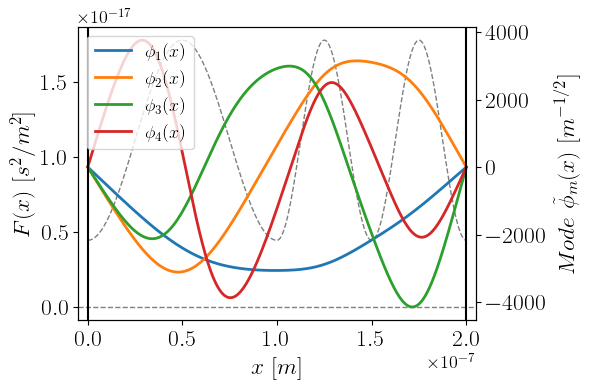

0
1
2
3
4


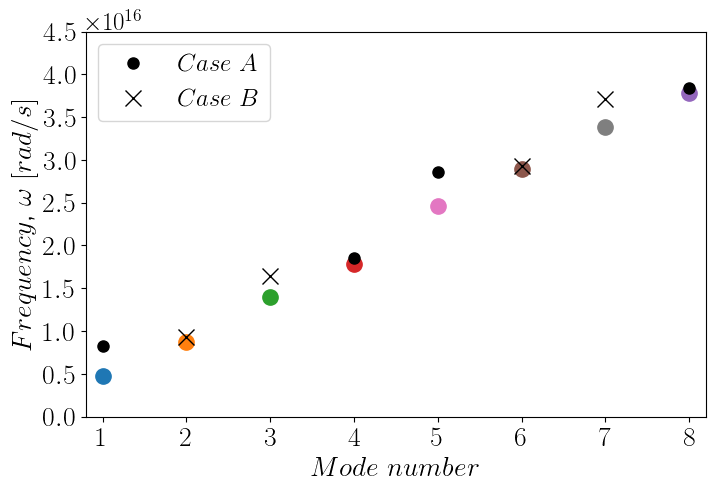

eig residual (rel inf) after L2 rescale = 4.670e-12
[ 2.13321997e-16  1.14408854e-16  7.13708989e-17  5.61870536e-17
  4.06368254e-17  3.45409772e-17  2.95177028e-17  2.64291830e-17
 -1.89449546e-32 -7.97993744e-32 -1.44707939e-32 -6.13256343e-32]
[ 6.33671294e-08  3.17708694e-08  2.08163009e-08  1.62228505e-08
  1.32198642e-08  1.07518863e-08  9.27615455e-09  8.01417743e-09
 -6.10021705e-24 -2.52675830e-23 -4.59382877e-24 -1.89651565e-23]
||u_eps - u_L2|| / ||u_eps|| = 1.3078362560065818e-16
[2.13321997e-16 1.14408854e-16 7.13708989e-17 5.61870536e-17
 4.06368254e-17 3.45409772e-17 2.95177028e-17 2.64291830e-17
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
[Energy check] max|E_modal - E_quad| / E0 = 2.274e-13
[Energy check] rel variation of E_quad   = 9.049e-13
E per selected mode at t=0: [2.26659125e-08 2.59352874e-08 2.35106813e-08 2.39909907e-08
 1.88979873e-08 2.06409607e-08 2.02515914e-08 2.17510169e-08]
S_nn for selected modes   : [4.53318250e-08 5.18705748e-08 4

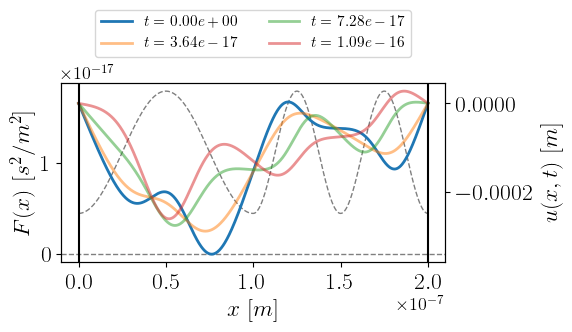

1.7764442816422546e-07


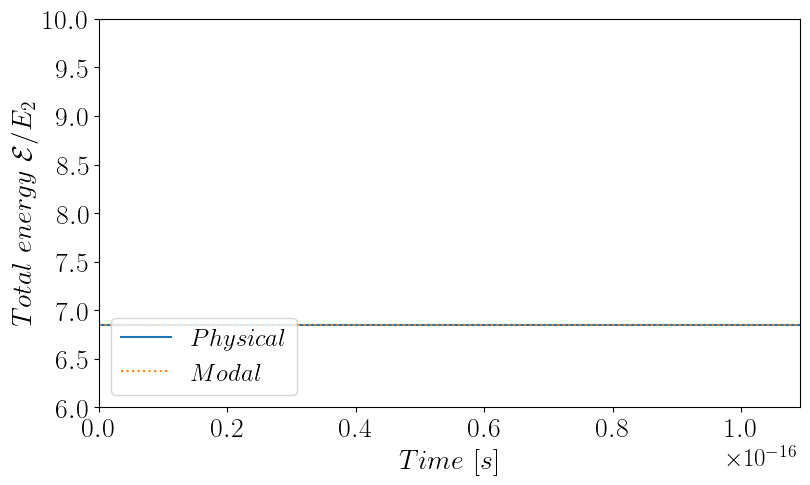

0
1
2


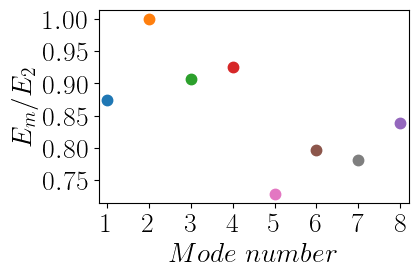

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [65]:
# ---- sub‑medium definitions  (same numbers you used) -----------------
medium_A = (eps0*mu0, -0.6*eps0*mu0, 100e-9, 1)   # eps0, eps1, lam, m
medium_B = (eps0*mu0, -0.6*eps0*mu0, 100e-9/2, 2)

x, FFF, o0_bands, Phi_bands = slab_concat(
        params_A = medium_A,
        params_B = medium_B,
        ppp      = 100,
        n_bands  = 4)

print("First omeg0:", np.concatenate(o0_bands))



from matplotlib.ticker import ScalarFormatter



# --- Plot first N modes along with F(x) on a twin y-axis
N = 4  # Number of modes to plot

fonty = 17
fig, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)

# Plot the first N modes from flattened Phi_bands
Phi_eps = np.hstack(Phi_bands)  # shape: (Nx, total_modes)
omega   = np.concatenate(o0_bands)      # (K,)
Nx, K   = Phi_eps.shape
#for n in range(N):
#    ax1.plot(x, Phi_all[:, n], label=f"Mode {n+1}", linewidth=2)

# ---------- Make an L2-rescaled copy (per column only) ----------
# Use simple trapz for L2; (optionally) trapezoid weights W if you prefer.
l2 = np.sqrt(np.trapz(Phi_eps**2, x, axis=0))   # shape (K,)
Phi_L2 = Phi_eps / l2                           # still exact eigenvectors


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
for n in range(N):
    print(n)
    line, = ax1.plot(x, Phi_L2[:, n], label=fr"$\phi_{n+1}(x)$", linewidth=2)
    lines.append(line)
    
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$Mode$ $\tilde{\phi}_m(x)$ $[m^{-1/2}]$', fontsize=fonty)
ax1.legend(loc="upper left",fontsize=fonty-4)
ax1.set_xlim(-100e-9*0.05, 2*100e-9+100e-9*0.05)

ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)

#ax = plt.gca()
#ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
#ax.xaxis.get_offset_text().set_fontsize(fonty)  # adjust size of 10^ exponent

# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(2*100e-9, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Modesfinite_classic_concatenate.png', format='png', dpi=1000, bbox_inches='tight')






markinhos  = 22
fonty = 20
fig4 = plt.figure(4, figsize=(8, 5))
plt.rc('text', usetex=True)

flat_array = np.concatenate(o0_bands)  # shape: (total_modes,)
for b, oo in enumerate(flat_array[0:5],start=0):
    print(b)
    if b < N-1:
        color = lines[b].get_color()  # use same color as the mode line
        plt.plot(b,oo,'.',markersize=markinhos, alpha=1,color=color)        

color = 'tab:red'  # fallback color
plt.plot(3,flat_array[3],'.',markersize=markinhos, alpha=1,color=color)
color = 'tab:pink'  # fallback color
plt.plot(4,flat_array[4],'.',markersize=markinhos, alpha=1,color=color)
color = 'tab:brown'  # fallback color
plt.plot(5,flat_array[5],'.',markersize=markinhos, alpha=1,color=color)       
color = 'tab:gray'  # fallback color
plt.plot(6,flat_array[6],'.',markersize=markinhos, alpha=1,color=color)       
color = 'tab:purple'  # fallback color
plt.plot(7,flat_array[7],'.',markersize=markinhos, alpha=1,color=color)       
                            
    
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$Frequency$, $\omega$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

plt.plot(0,8234007362546864,'k.',markersize=16,label=r'$Case$ $A$')
plt.plot(3,18569305998567964,'k.',markersize=16)
plt.plot(4,28576666903638436,'k.',markersize=16)
plt.plot(7,38425833924903272,'k.',markersize=16)

plt.plot(1,9349593508535952,'kx',markersize=11)
plt.plot(2,16468014725088300,'kx',markersize=11)
plt.plot(5,29331266742028508,'kx',markersize=11,label=r'$Case$ $B$')
plt.plot(6,37138611997143528,'kx',markersize=11)


# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

#plt.xlim(-1.2*kmax, 1.2*kmax)   # set the ylim to ymin, ymax
plt.xlim(-0.2,7.2)   # set the ylim to ymin, ymax
plt.ylim(0., 4.5e16)   # set the ylim to ymin, ymax
plt.legend(loc="upper left",fontsize=fonty-2)
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1, 2, 3,4,5,6,7], [r'$1$',r'$2$',r'$3$',r'$4$',r'$5$',r'$6$',r'$7$',r'$8$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Frequency_concatenate_1.png', format='png', dpi=1000, bbox_inches='tight')



# (Sanity) M-orthogonality off-diagonals stay ~0; diagonals are not ±1 anymore
Mmat    = np.diag(FFF[1:-1])
Phi_int = Phi_L2[1:-1, :]
S = Phi_int.T @ (Mmat @ Phi_int)                # Φᵀ M Φ   (K,K)
# Build T on interior exactly as in your solver
dx   = x[1] - x[0]
Nint = Phi_int.shape[0]
main =  2.0*np.ones(Nint)/dx**2
off  = -1.0*np.ones(Nint-1)/dx**2
Tmat = np.diag(main) + np.diag(off,1) + np.diag(off,-1)
Kmat = Phi_int.T @ (Tmat  @ Phi_int)            # Φᵀ T Φ   (K,K)

# (Optional) verify eigen relation still holds (it does; scaling doesn’t change it)
res = Tmat @ Phi_int - Mmat @ (Phi_int * (omega**2))
rel_inf = np.linalg.norm(res, np.inf) / (np.linalg.norm(Tmat @ Phi_int, np.inf) + 1e-300)
print("eig residual (rel inf) after L2 rescale =", f"{rel_inf:.3e}")



# ---------- Choose initial modal amplitudes using L2 interpretation ----------
# --- Choose initial modal amplitudes q(0)
u0 = 1*(Phi_eps[:, 0]/omega[0]+Phi_eps[:, 1]/omega[1]+Phi_eps[:, 2]/omega[2] + Phi_eps[:, 3]/omega[3]+Phi_eps[:, 4]/omega[4] + Phi_eps[:, 5]/omega[5]+Phi_eps[:, 6]/omega[6] + Phi_eps[:, 7]/omega[7])
#u0 = 1*(Phi_eps[:, 0]/omega[0]+ Phi_eps[:, 3]/omega[3])
q_eps = np.trapz(FFF[:, None] * u0[:, None] * Phi_eps, x, axis=0)
print(q_eps)
qL2 = q_eps * l2                               # D^{-1} q_eps
print(qL2)

# Field consistency check
u_from_eps = Phi_eps @ q_eps
u_from_L2  = Phi_L2  @ (l2 * q_eps)    # must match u_from_eps
print("||u_eps - u_L2|| / ||u_eps|| =",
      np.linalg.norm(u_from_eps - u_from_L2) / (np.linalg.norm(u_from_eps) + 1e-300))


# Example: equal-energy-by-displacement: q_n(0) = 1/ω_n (you can choose any rule)
q0  = np.zeros(K)
pick = [0,1,2, 3,4,5,6,7] # modes you want
q0[pick] = 1.0 / omega[pick]
print(q0)
dq0 = np.zeros_like(q0)

# ---------- Reconstruct fields and compute energy (normalization-agnostic) ----------
# Time evolution (decoupled cosines) is valid since columns are still eigenvectors
Tfinal = 2*np.pi/np.max(omega)
Nt = 1000
t  = np.linspace(0.0, Tfinal, Nt)
q  = q0 * np.cos(np.outer(t, omega))            # (Nt,K)
dq = -q0 * omega * np.sin(np.outer(t, omega))   # (Nt,K)
qL2  = qL2 * np.cos(np.outer(t, omega))            # (Nt,K)
dqL2 = -qL2 * omega * np.sin(np.outer(t, omega))   # (Nt,K)

# Energy via general modal form (works for ANY normalization)
E_modal = 0.5 * (np.einsum('ti,ij,tj->t', dq, S, dq) +
                 np.einsum('ti,ij,tj->t',  q, Kmat, q))

# (Cross-check) energy via physical-space quadratic form
u  = q @ Phi_eps.T                                      # (Nt, Nx)
ut = dq @ Phi_eps.T                                     # (Nt, Nx)
uL2  = qL2 @ Phi_L2.T                                      # (Nt, Nx)
utL2 = dqL2 @ Phi_L2.T                                     # (Nt, Nx)
u_int  = q  @ Phi_int.T
ut_int = dq @ Phi_int.T
E_quad = 0.5 * (np.einsum('ti,ij,tj->t', ut_int, Mmat, ut_int) +
                np.einsum('ti,ij,tj->t',  u_int,  Tmat,  u_int))


E0 = E_quad[0]
print(f"[Energy check] max|E_modal - E_quad| / E0 = {np.max(np.abs(E_modal - E_quad))/E0:.3e}")
print(f"[Energy check] rel variation of E_quad   = {np.ptp(E_quad)/E0:.3e}")

# ---------- Per-mode energy at t=0 (with dq0=0) ----------
# For exact eigenvectors: Kmat ≈ S @ diag(ω^2), so E_n(0) ≈ 0.5 * S_nn * (1)
E_modes_0 = 0.5 * (q0**2) * np.diag(Kmat)
print("E per selected mode at t=0:", E_modes_0[pick])
print("S_nn for selected modes   :", np.diag(S)[pick])





fonty = 17
fig1, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
snap_idx = np.linspace(0, Nt-1, 4, dtype=int)
for si in snap_idx:
    if si < 1:
        line, = ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2)
        lines.append(line)
    else:
        line, = ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2,alpha=0.5)
        lines.append(line)
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$u(x,t)$ $[m]$', fontsize=fonty)
ax1.legend(loc='upper center',
    bbox_to_anchor=(0.5, 1.45),
    ncol=2,fontsize=fonty-6)
#ax1.legend(loc="upper left",fontsize=fonty-6)
#ax1.legend(loc="upper left",fontsize=fonty-6)
ax1.set_xlim(-200e-9*0.05, 200e-9+200e-9*0.05)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)


# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(200e-9, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig1.savefig('Evol_disp_classic_concatenate_inabox.png', format='png', dpi=1000, bbox_inches='tight')



print(E0)
# -- Plots
fonty = 20
fig5 = plt.figure(5, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.plot(t, E_quad/E_modes_0[1],           label=r'$Physical$')
plt.plot(t, E_modal/E_modes_0[1], ':', label=r'$Modal$')

plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$Time$ $[s]$',fontsize=fonty)
plt.ylabel(r'$Total$ $energy$ $\mathcal{E}/E_2$',fontsize=fonty)
plt.legend(loc="lower left",fontsize=fonty-2); 
plt.tight_layout()
plt.xlim(0,t[-1])
plt.ylim(6,10)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.show()

fig5.savefig('Energy_evol_classic_concatenate_inabox.png', format='png', dpi=1000, bbox_inches='tight')




fonty = 20
fig4 = plt.figure(4, figsize=(4, 2.5))
plt.rc('text', usetex=True)

#plt.axhline(y=E_modes_0[-1]/100e-9,color="black", lw=1.,linestyle='--')
#plt.plot(pick,E_modes_0[pick]/100e-9,'.',markersize=15)         
#plt.legend(loc="upper left",fontsize=fonty-2)    
for b, oo in enumerate(flat_array[0:N-1],start=0):
    if b < N-1:
        print(b)
        color = lines[b].get_color()  # match mode color
        plt.plot(b,E_modes_0[b]/E_modes_0[1],'.',markersize=15., alpha=1,color=color)
        
color = 'tab:red'  # fallback color
plt.plot(3,E_modes_0[3]/E_modes_0[1],'.',markersize=15., alpha=1,color=color)
color = 'tab:pink'  # fallback color
plt.plot(4,E_modes_0[4]/E_modes_0[1],'.',markersize=15., alpha=1,color=color)
color = 'tab:brown'  # fallback color
plt.plot(5,E_modes_0[5]/E_modes_0[1],'.',markersize=15., alpha=1,color=color)       
color = 'tab:gray'  # fallback color
plt.plot(6,E_modes_0[6]/E_modes_0[1],'.',markersize=15., alpha=1,color=color)       
color = 'tab:purple'  # fallback color
plt.plot(7,E_modes_0[7]/E_modes_0[1],'.',markersize=15., alpha=1,color=color)  
        
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$E_m/E_2$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-0.2, 7.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(0., 1.5)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1, 2, 3,4,5,6,7], [r'$1$',r'$2$',r'$3$',r'$4$',r'$5$',r'$6$',r'$7$',r'$8$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Energy_per_mode_evol_classic_concatenate_inabox.png', format='png', dpi=1000, bbox_inches='tight')



print(np.sqrt(np.trapz(Phi_L2**2, x, axis=0)))

## By Arnaud Lazarus - 06/13/2026